# Model 2 - TransUNet

In [ ]:
import subprocess, sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'],stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _pkg in ['medpy', 'albumentations']:
    try:
        __import__(_pkg)
    except ImportError:
        _pip_install(_pkg)

print(' All dependencies ready')

 All dependencies ready


In [101]:
import os, random, warnings, time, math
import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import albumentations as A

from pathlib import Path
from copy import deepcopy
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from albumentations.pytorch import ToTensorV2
from medpy.metric.binary import hd95

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})

print(f'  PyTorch : {torch.__version__}')
print(f'  CUDA    : {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})')

  PyTorch : 2.10.0+cu128
  CUDA    : True (Tesla T4)


In [ ]:
class CFG:
    SEED = 67
    IMAGE_SIZE = 224
    BATCH_SIZE = 8
    LR = 1e-4
    EPOCHS = 100
    WEIGHT_DECAY = 1e-5
    FOCAL_ALPHA = 0.25        
    FOCAL_GAMMA = 2.0       
    FOCAL_WEIGHT = 0.4        
    DICE_WEIGHT = 0.6     
    VIT_PATCHES = 14         
    VIT_HIDDEN = 768         
    VIT_LAYERS = 12          
    VIT_HEADS = 12          
    VIT_MLP_DIM = 3072     
    VIT_DROPOUT = 0.1
    DECODER_CH = [256, 128, 64, 16]
    IN_CHANNELS = 1
    OUT_CHANNELS = 1
    DATA_ROOT = Path('/kaggle/input/datasets/prabhanshu22/dac-dataset/processed')
    TRAIN_DIR = DATA_ROOT / 'train'
    VAL_DIR = DATA_ROOT / 'val'
    TEST_DIR = DATA_ROOT / 'test'
    CKPT_DIR = Path('/kaggle/working/models')
    BEST_CKPT = CKPT_DIR / 'transunet_best.pth'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.SEED)
CFG.CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f' Config  |  Device: {CFG.DEVICE}  |  Seed: {CFG.SEED}')
print(f'  ViT     : {CFG.VIT_LAYERS} layers  {CFG.VIT_HEADS} heads  dim={CFG.VIT_HIDDEN}')
print(f'  Patches : {CFG.VIT_PATCHES}×{CFG.VIT_PATCHES} = {CFG.VIT_PATCHES**2} tokens')

 Config  |  Device: cuda  |  Seed: 67
  ViT     : 12 layers  12 heads  dim=768
  Patches : 14×14 = 196 tokens


## Loading the data 

In [49]:
class BRISCDataset(Dataset):
    def __init__(self, split_dir: Path, transform=None):
        self.transform = transform
        self.image_paths = sorted((split_dir / 'images').glob('*.npy'))
        self.mask_paths = [split_dir / 'masks' / p.name for p in self.image_paths]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.load(self.image_paths[idx]).astype(np.float32)
        mask = np.load(self.mask_paths[idx]).astype(np.float32)
        if img.ndim == 3:
            img = img[..., 0] if img.shape[-1] <= 4 else img[0]

        mn, mx = img.min(), img.max()
        img = (img - mn) / (mx - mn + 1e-8)
        img = np.clip(img, 0.0, 1.0)         
        img_3ch = np.stack([img, img, img], axis=-1).astype(np.float32)
        mask_2d = (mask > 0.5).astype(np.float32)

        if self.transform:
            out = self.transform(image=img_3ch, mask=mask_2d)
            img_t = out['image'][:1]
            mask_t = out['mask'].unsqueeze(0).float()
        else:
            img_t = torch.from_numpy(img_3ch.transpose(2,0,1))[:1]
            mask_t = torch.from_numpy(mask_2d).unsqueeze(0)

        return img_t, mask_t

In [50]:
SZ = CFG.IMAGE_SIZE

def get_train_transforms():
    return A.Compose([
        A.Resize(SZ, SZ),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.ElasticTransform(alpha=120, sigma=6, alpha_affine=6, p=0.4),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
        A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
        A.Normalize(mean=(0.0,), std=(1.0,)),
        ToTensorV2(),])

def get_val_transforms():
    return A.Compose([A.Resize(SZ, SZ),A.Normalize(mean=(0.0,), std=(1.0,)),ToTensorV2(),])

In [51]:
train_ds = BRISCDataset(CFG.TRAIN_DIR, transform=get_train_transforms())
val_ds = BRISCDataset(CFG.VAL_DIR, transform=get_val_transforms())
test_ds = BRISCDataset(CFG.TEST_DIR, transform=get_val_transforms())

_kw = dict(batch_size=CFG.BATCH_SIZE, num_workers=2, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True, **_kw)
val_loader = DataLoader(val_ds, shuffle=False, **_kw)
test_loader = DataLoader(test_ds, shuffle=False, **_kw)

print(f'Train : {len(train_ds):>5} slices  ({len(train_loader):>4} batches)')
print(f'Val   : {len(val_ds):>5} slices  ({len(val_loader):>4} batches)')
print(f'Test  : {len(test_ds):>5} slices  ({len(test_loader):>4} batches)')

imgs, masks = next(iter(train_loader))
print(f'\nBatch -> image {tuple(imgs.shape)}  mask {tuple(masks.shape)}')
print(f'Image range [{imgs.min():.3f}, {imgs.max():.3f}]  |  Mask unique {masks.unique().tolist()}')

Train :  3343 slices  ( 418 batches)
Val   :   590 slices  (  74 batches)
Test  :   860 slices  ( 108 batches)

Batch -> image (8, 1, 224, 224)  mask (8, 1, 224, 224)
Image range [0.000, 0.004]  |  Mask unique [0.0, 1.0]



## Architecture — Trans-UNet

In [52]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_ch: int, hidden_dim: int, num_patches: int):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, hidden_dim, kernel_size=1)
        self.pos_emb = nn.Parameter(torch.zeros(1, num_patches, hidden_dim))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

    def forward(self, x):
        x = self.proj(x)                         
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)          
        x = x + self.pos_emb[:, :H*W, :]
        return x, H, W

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, hidden_dim: int, num_heads: int, dropout: float = 0.0):
        super().__init__()
        assert hidden_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(hidden_dim, hidden_dim * 3)
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)                 
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)

class TransformerBlock(nn.Module):
    def __init__(self, hidden_dim: int, num_heads: int, mlp_dim: int, dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.attn = MultiHeadSelfAttention(hidden_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, hidden_dim),
            nn.Dropout(dropout),)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class ViTEncoder(nn.Module):
    def __init__(self, hidden_dim: int, num_layers: int, num_heads: int, mlp_dim: int, dropout: float = 0.0):
        super().__init__()
        self.layers = nn.ModuleList([TransformerBlock(hidden_dim, num_heads, mlp_dim, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.norm(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if x.shape[2:] != skip.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([skip, x], dim=1)
        return self.conv(x)

In [53]:
class TransUNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V1)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        nn.init.kaiming_normal_(resnet.conv1.weight, mode='fan_out', nonlinearity='relu')
        self.enc0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)           
        self.pool = resnet.maxpool                       
        self.enc1 = resnet.layer1                       
        self.enc2 = resnet.layer2                        
        self.enc3 = resnet.layer3                       
        self.enc4 = resnet.layer4                       
        num_patches = CFG.VIT_PATCHES * CFG.VIT_PATCHES  
        
        self.patch_emb = PatchEmbedding(2048, CFG.VIT_HIDDEN, num_patches)
        self.vit = ViTEncoder(CFG.VIT_HIDDEN, CFG.VIT_LAYERS, CFG.VIT_HEADS, CFG.VIT_MLP_DIM, CFG.VIT_DROPOUT)
        self.vit_proj = nn.Conv2d(CFG.VIT_HIDDEN, 512, kernel_size=1)
        self.dec3 = DecoderBlock(512, 1024, 256)
        self.dec2 = DecoderBlock(256, 512, 128)
        self.dec1 = DecoderBlock(128, 256, 64)
        self.dec0 = DecoderBlock(64, 64, 16)
        self.dec_final = DecoderBlock(16, 0, 16)
        self.head = nn.Conv2d(16, CFG.OUT_CHANNELS, kernel_size=1)

    def forward(self, x):
        s0 = self.enc0(x)          
        p  = self.pool(s0)        
        s1 = self.enc1(p)          
        s2 = self.enc2(s1)         
        s3 = self.enc3(s2)         
        b = self.enc4(s3)         
        tokens, H, W = self.patch_emb(b)          
        tokens = self.vit(tokens)            
        feat = tokens.transpose(1, 2).reshape(-1, CFG.VIT_HIDDEN, H, W)
        feat = self.vit_proj(feat)                 
        d = self.dec3(feat, s3)   
        d = self.dec2(d, s2)    
        d = self.dec1(d, s1)    
        d = self.dec0(d, s0)    
        d = self.dec_final(d)    
        return self.head(d)       

In [54]:
model = TransUNet().to(CFG.DEVICE)

def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def print_param_summary(m):
    hdr = f"{'Module':<20} {'Type':<25} {'Params':>12}"
    print('─' * len(hdr))
    print(hdr)
    print('─' * len(hdr))
    for name, mod in m.named_children():
        p = sum(x.numel() for x in mod.parameters())
        print(f'{name:<20} {type(mod).__name__:<25} {p:>12,}')
    print('─' * len(hdr))
    tot, trn = count_params(m)
    print(f"{'Total':<20} {'':.<25} {tot:>12,}")
    print(f"{'Trainable':<20} {'':.<25} {trn:>12,}")
    print('─' * len(hdr))

print_param_summary(model)
tot, _ = count_params(model)
print(f'\n  ≈ {tot/1e6:.1f} M parameters')

───────────────────────────────────────────────────────────
Module               Type                            Params
───────────────────────────────────────────────────────────
enc0                 Sequential                       3,264
pool                 MaxPool2d                            0
enc1                 Sequential                     215,808
enc2                 Sequential                   1,219,584
enc3                 Sequential                   7,098,368
enc4                 Sequential                  14,964,736
patch_emb            PatchEmbedding               1,724,160
vit                  ViTEncoder                  85,056,000
vit_proj             Conv2d                         393,728
dec3                 DecoderBlock                 4,129,792
dec2                 DecoderBlock                 1,032,704
dec1                 DecoderBlock                   258,304
dec0                 DecoderBlock                    20,800
dec_final            DecoderBlock       

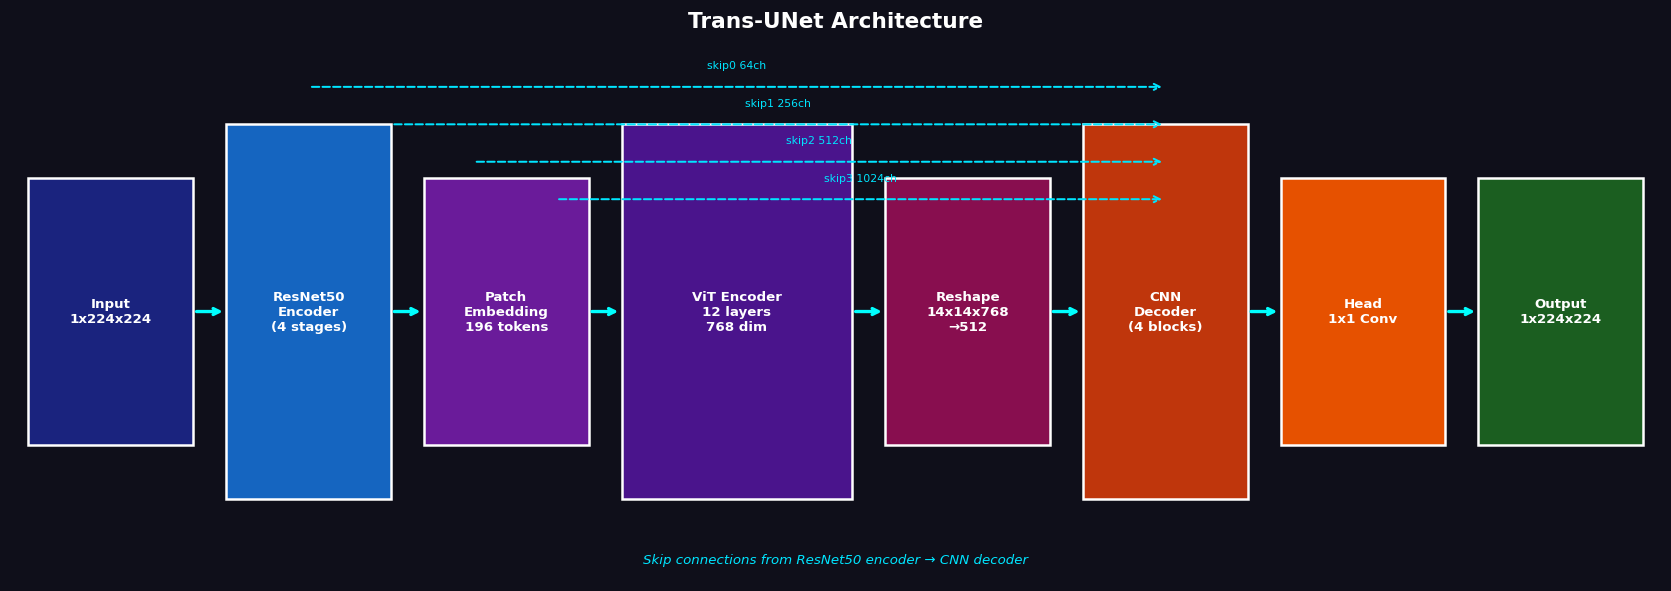

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

boxes = [
    (0.01, 0.25, 0.10, 0.50, 'Input\n1x224x224', '#1a237e'),
    (0.13, 0.15, 0.10, 0.70, 'ResNet50\nEncoder\n(4 stages)', '#1565c0'),
    (0.25, 0.25, 0.10, 0.50, 'Patch\nEmbedding\n196 tokens', '#6a1b9a'),
    (0.37, 0.15, 0.14, 0.70, 'ViT Encoder\n12 layers\n768 dim','#4a148c'),
    (0.53, 0.25, 0.10, 0.50, 'Reshape\n14x14x768\n→512', '#880e4f'),
    (0.65, 0.15, 0.10, 0.70, 'CNN\nDecoder\n(4 blocks)', '#bf360c'),
    (0.77, 0.25, 0.10, 0.50, 'Head\n1x1 Conv', '#e65100'),
    (0.89, 0.25, 0.10, 0.50, 'Output\n1x224x224', '#1b5e20'),]

for (x, y, w, h, lbl, col) in boxes:
    rect = plt.Rectangle((x, y), w, h, facecolor=col, edgecolor='white', linewidth=1.5, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, lbl, ha='center', va='center', fontsize=8, color='white', fontweight='bold', transform=ax.transAxes)

for i in range(len(boxes)-1):
    x1 = boxes[i][0] + boxes[i][2]
    x2 = boxes[i+1][0]
    y = boxes[i][1] + boxes[i][3] / 2
    ax.annotate('', xy=(x2, y), xytext=(x1, y),xycoords='axes fraction', textcoords='axes fraction',arrowprops=dict(arrowstyle='->', color='cyan', lw=2))

for (x_from, x_to, y_arc, lbl) in [
    (0.18, 0.70, 0.92, 'skip0 64ch'),
    (0.23, 0.70, 0.85, 'skip1 256ch'),
    (0.28, 0.70, 0.78, 'skip2 512ch'),
    (0.33, 0.70, 0.71, 'skip3 1024ch'),
]:
    ax.annotate('', xy=(x_to, y_arc), xytext=(x_from, y_arc),xycoords='axes fraction', textcoords='axes fraction', arrowprops=dict(arrowstyle='->', color='#00e5ff',lw=1.2, linestyle='dashed'))
    ax.text((x_from+x_to)/2, y_arc+0.03, lbl, ha='center', va='bottom', fontsize=6.5, color='#00e5ff', transform=ax.transAxes)

ax.text(0.5, 0.03, 'Skip connections from ResNet50 encoder → CNN decoder', ha='center', fontsize=8, color='#00e5ff', style='italic', transform=ax.transAxes)
ax.set_title('Trans-UNet Architecture', color='white', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('/kaggle/working/transunet_architecture.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = F.binary_cross_entropy_with_logits( logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal = alpha_t * (1.0 - p_t) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal.mean()
        if self.reduction == 'sum':
            return focal.sum()
        return focal  

class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        num = 2.0 * (probs * targets).sum(dim=(2, 3)) + self.smooth
        den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + self.smooth
        return (1.0 - (num / den)).mean()

class FocalDiceLoss(nn.Module):
    def __init__(self,
                 alpha: float = CFG.FOCAL_ALPHA,
                 gamma: float = CFG.FOCAL_GAMMA,
                 focal_weight: float = CFG.FOCAL_WEIGHT,
                 dice_weight: float = CFG.DICE_WEIGHT,
                 smooth: float = 1e-6):
        super().__init__()
        assert abs(focal_weight + dice_weight - 1.0) < 1e-6, \
        self.focal = FocalLoss(alpha=alpha, gamma=gamma)
        self.dice = DiceLoss(smooth=smooth)
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return (self.focal_weight * self.focal(logits, targets) + self.dice_weight  * self.dice(logits,  targets))
        
criterion = FocalDiceLoss().to(CFG.DEVICE)
optimizer = torch.optim.AdamW([
    {'params': model.enc0.parameters(), 'lr': CFG.LR * 0.1},
    {'params': model.enc1.parameters(), 'lr': CFG.LR * 0.1},
    {'params': model.enc2.parameters(), 'lr': CFG.LR * 0.1},
    {'params': model.enc3.parameters(), 'lr': CFG.LR * 0.1},
    {'params': model.enc4.parameters(), 'lr': CFG.LR * 0.1},
    {'params': model.patch_emb.parameters(), 'lr': CFG.LR * 0.5},
    {'params': model.vit.parameters(), 'lr': CFG.LR * 0.5},
    {'params': model.vit_proj.parameters(), 'lr': CFG.LR * 0.5},
    {'params': model.dec3.parameters(), 'lr': CFG.LR},
    {'params': model.dec2.parameters(), 'lr': CFG.LR},
    {'params': model.dec1.parameters(), 'lr': CFG.LR},
    {'params': model.dec0.parameters(), 'lr': CFG.LR},
    {'params': model.dec_final.parameters(), 'lr': CFG.LR},
    {'params': model.head.parameters(), 'lr': CFG.LR},
], weight_decay=CFG.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)

print(f'  FocalDiceLoss  |  α={CFG.FOCAL_ALPHA}  γ={CFG.FOCAL_GAMMA}')
print(f'  Optimiser      |  AdamW  layer-wise LR')
print(f'  Scheduler      |  CosineAnnealingLR  T_max={CFG.EPOCHS}')
print()
print(f'  Encoder  : {CFG.LR * 0.1:.1e}')
print(f'  ViT      : {CFG.LR * 0.5:.1e}')
print(f'  Decoder  : {CFG.LR:.1e}')

  FocalDiceLoss  |  α=0.25  γ=2.0
  Optimiser      |  AdamW  layer-wise LR
  Scheduler      |  CosineAnnealingLR  T_max=100

  Encoder  : 1.0e-05
  ViT      : 5.0e-05
  Decoder  : 1.0e-04



## Training

In [57]:
def dice_score(pred, target, smooth=1e-6):
    inter = (pred * target).sum()
    return (2*inter + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter + smooth) / (union + smooth)

def batch_metrics(logits, masks, threshold=0.5):
    probs = torch.sigmoid(logits).detach().cpu().numpy()
    masks_np = masks.cpu().numpy()
    preds = (probs > threshold).astype(np.float32)
    dices, ious = [], []
    for p, t in zip(preds, masks_np):
        dices.append(dice_score(p, t))
        ious.append(iou_score(p, t))
    return np.mean(dices), np.mean(ious)

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None, device=CFG.DEVICE, train=True):
    model.train(train)
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            if train:
                optimizer.zero_grad()
                with autocast():
                    logits = model(imgs)
                    loss = criterion(logits, masks)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                if not torch.isfinite(loss):         
                    optimizer.zero_grad()
                    scaler.update()
                    continue
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast():
                    logits = model(imgs)
                    loss = criterion(logits, masks)

            d, iou = batch_metrics(logits, masks)
            if torch.isfinite(loss):             
                total_loss += loss.item()
            total_dice += d
            total_iou += iou

    n = len(loader)
    return total_loss/n, total_dice/n, total_iou/n

In [ ]:
scaler = GradScaler(init_scale=2**14, growth_interval=200)  
history = {'train_loss':[], 'val_loss':[],'train_dice':[], 'val_dice':[],'train_iou': [], 'val_iou': [],'lr': [],}

best_val_dice = -1.0
best_epoch = 0
hdr = (f"{'Epoch':>6}  {'T-Loss':>8}  {'V-Loss':>8}  "
       f"{'T-Dice':>8}  {'V-Dice':>8}  {'V-IoU':>8}  "
       f"{'LR':>10}  {'Time':>7}")
print(hdr)
print('─' * len(hdr))

for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_dice, tr_iou = run_epoch(model, train_loader, criterion, optimizer, scaler, train=True)
    va_loss, va_dice, va_iou = run_epoch(model, val_loader, criterion, train=False)
    scheduler.step()
    cur_lr = scheduler.get_last_lr()[0]

    for k, v in zip(['train_loss','val_loss','train_dice','val_dice','train_iou','val_iou','lr'],
        [tr_loss, va_loss, tr_dice, va_dice, tr_iou, va_iou, cur_lr]):
        history[k].append(v)

    saved_flag = ''
    if va_dice > best_val_dice:
        best_val_dice = va_dice
        best_epoch    = epoch
        torch.save({
            'epoch': epoch,
            'state_dict': deepcopy(model.state_dict()),
            'val_dice': float(va_dice),
            'val_iou': float(va_iou),
        }, CFG.BEST_CKPT)
        saved_flag = ' ★'
        
    elapsed = time.time() - t0
    print(f'{epoch:>6}  {tr_loss:>8.4f}  {va_loss:>8.4f}  '
          f'{tr_dice:>8.4f}  {va_dice:>8.4f}  {va_iou:>8.4f}  '
          f'{cur_lr:>10.2e}  {elapsed:>6.1f}s{saved_flag}')

print('─' * len(hdr))
print(f'\n Training complete  |  Best Val Dice: {best_val_dice:.4f} @ epoch {best_epoch}')

 Epoch    T-Loss    V-Loss    T-Dice    V-Dice     V-IoU          LR     Time
─────────────────────────────────────────────────────────────────────────────
     1    0.6135    0.5913    0.2606    0.5348    0.3916    1.00e-05    66.7s ★
     2    0.5857    0.5737    0.4663    0.5509    0.4211    9.99e-06    66.3s ★
     3    0.5597    0.5403    0.5007    0.5053    0.3792    9.98e-06    65.3s
     4    0.5192    0.5003    0.4503    0.3646    0.2931    9.96e-06    66.3s
     5    0.4818    0.4186    0.4329    0.6619    0.5513    9.94e-06    66.3s ★
     6    0.4366    0.3206    0.4338    0.6736    0.5752    9.92e-06    67.1s ★
     7    0.4008    0.3094    0.5382    0.7400    0.6361    9.89e-06    66.6s ★
     8    0.3658    0.2610    0.6403    0.7551    0.6646    9.86e-06    66.5s ★
     9    0.3280    0.2441    0.6672    0.7690    0.6767    9.82e-06    66.9s ★
    10    0.2996    0.2190    0.6833    0.7700    0.6720    9.78e-06    66.3s ★
    11    0.2725    0.1775    0.6935    0.7878  

## Evaluation 

In [60]:
ckpt = torch.load(CFG.BEST_CKPT, map_location=CFG.DEVICE, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f' Best checkpoint loaded  (epoch {ckpt["epoch"]}, Val Dice={ckpt["val_dice"]:.4f})')

 Best checkpoint loaded  (epoch 92, Val Dice=0.8645)


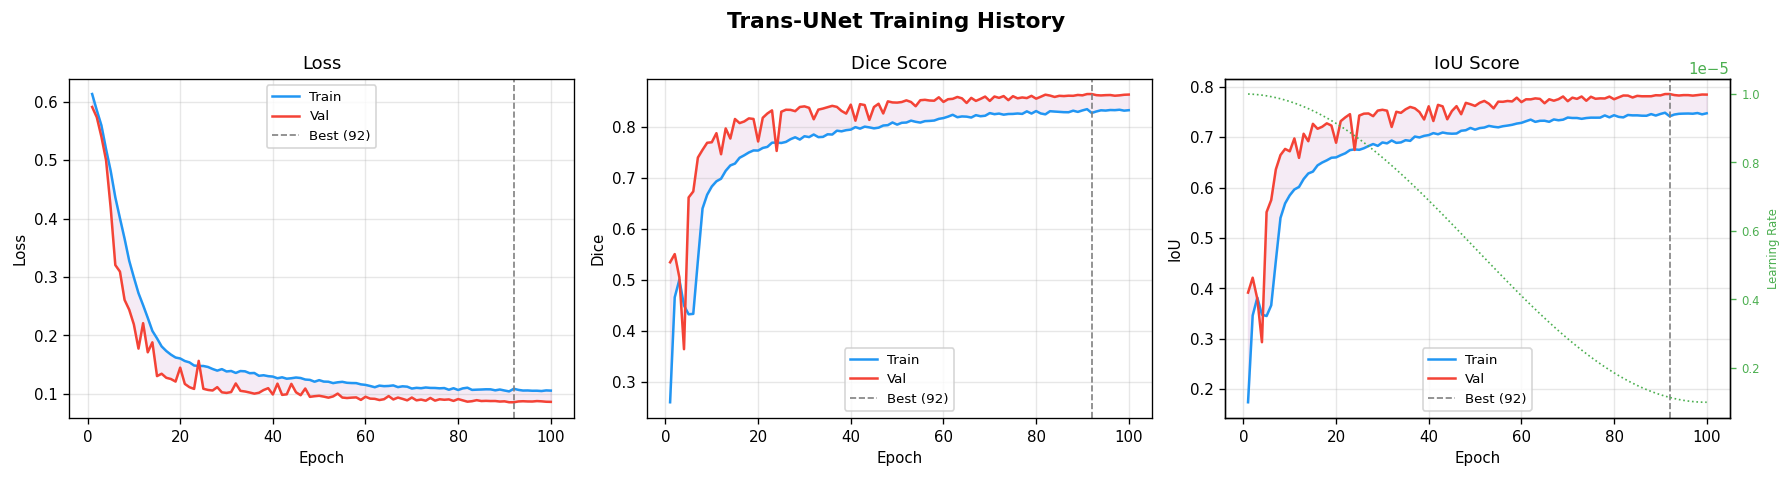

In [61]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Trans-UNet Training History', fontsize=13, fontweight='bold')
palette = {'train': '#2196F3', 'val': '#F44336'}

for ax, (tr_key, va_key, title, ylabel) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss','Loss'),
    ('train_dice', 'val_dice', 'Dice Score', 'Dice'),
    ('train_iou', 'val_iou', 'IoU Score', 'IoU'),]):
    
    ax.plot(epochs, history[tr_key], label='Train', color=palette['train'], lw=1.5)
    ax.plot(epochs, history[va_key], label='Val', color=palette['val'], lw=1.5)
    ax.axvline(best_epoch, ls='--', color='gray', lw=1, label=f'Best ({best_epoch})')
    ax.fill_between(epochs, history[tr_key], history[va_key], alpha=0.08, color='purple')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

ax2b = axes[2].twinx()
ax2b.plot(epochs, history['lr'], color='#4CAF50', lw=1, ls='dotted', label='LR')
ax2b.set_ylabel('Learning Rate', color='#4CAF50', fontsize=7)
ax2b.tick_params(axis='y', colors='#4CAF50', labelsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/transunet_history.png', bbox_inches='tight')
plt.show()

In [ ]:
@torch.no_grad()
def evaluate_metrics(model, loader, device=CFG.DEVICE, threshold=0.5):
    model.eval()
    records = []
    for imgs, masks in loader:
        logits = model(imgs.to(device))
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > threshold).astype(np.uint8)
        gts = masks.numpy().astype(np.uint8)
        
        for pred, gt in zip(preds, gts):
            p, t = pred[0], gt[0]
            tp = int((p & t).sum())
            tn = int(((1-p)&(1-t)).sum())
            fp = int((p & (1-t)).sum()); fn = int(((1-p)&t).sum())
            records.append(dict(
                dice = (2*tp+1e-6)/(2*tp+fp+fn+1e-6),
                iou = (tp+1e-6)/(tp+fp+fn+1e-6),
                precision = (tp+1e-6)/(tp+fp+1e-6),
                recall = (tp+1e-6)/(tp+fn+1e-6),
                specificity = (tn+1e-6)/(tn+fp+1e-6),
                hd95 = hd95(p,t) if p.sum()>0 and t.sum()>0 else np.nan,))
            
    return records

tr_records = evaluate_metrics(model, train_loader)
va_records = evaluate_metrics(model, val_loader)
te_records = evaluate_metrics(model, test_loader)

def make_summary(records, label):
    df = pd.DataFrame(records)
    row = {'Split': label}
    for col in df.columns:
        v = df[col].dropna()
        row[col.capitalize()] = f'{v.mean():.4f} ± {v.std():.4f}'
    return row

summary_df = pd.DataFrame([make_summary(tr_records, 'Train'),
    make_summary(va_records, 'Val'),make_summary(te_records, 'Test'),]).set_index('Split')

print('\nMetrics Summary \n')
print(summary_df.to_string())


Metrics Summary 

                  Dice              Iou        Precision           Recall      Specificity              Hd95
Split                                                                                                       
Train  0.8353 ± 0.1876  0.7491 ± 0.2025  0.8533 ± 0.1860  0.8477 ± 0.1929  0.9980 ± 0.0034  8.0074 ± 14.2817
Val    0.8647 ± 0.1584  0.7861 ± 0.1793  0.8852 ± 0.1627  0.8702 ± 0.1713  0.9984 ± 0.0030  6.8727 ± 13.2872
Test   0.8572 ± 0.1712  0.7790 ± 0.1971  0.8634 ± 0.1820  0.8784 ± 0.1735  0.9982 ± 0.0030  7.0788 ± 13.4179


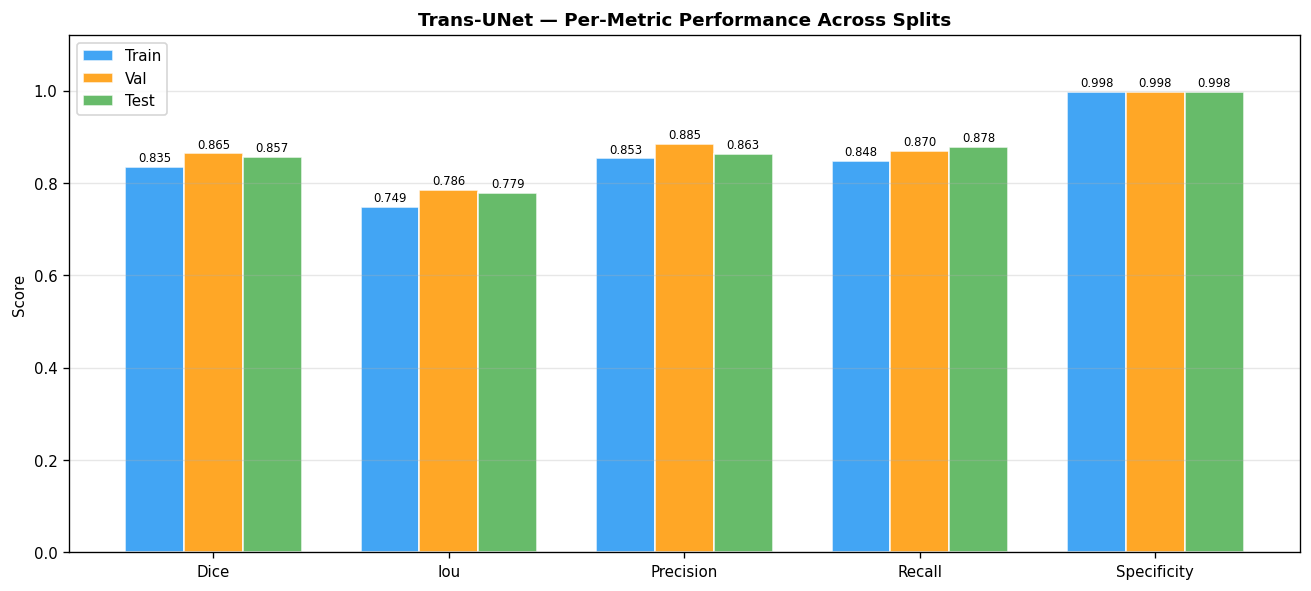

In [87]:
metrics = ['Dice','Iou','Precision','Recall','Specificity']
splits = ['Train','Val','Test']
records_map = {'Train': tr_records, 'Val': va_records, 'Test': te_records}
means = {s: [pd.DataFrame(records_map[s])[m.lower()].mean() for m in metrics] for s in splits}

x = np.arange(len(metrics))
w = 0.25
cols = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (split, col) in enumerate(zip(splits, cols)):
    bars = ax.bar(x + i*w, means[split], w, label=split, color=col, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, means[split]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + w)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Trans-UNet — Per-Metric Performance Across Splits', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/metric_bars.png', bbox_inches='tight')
plt.show()

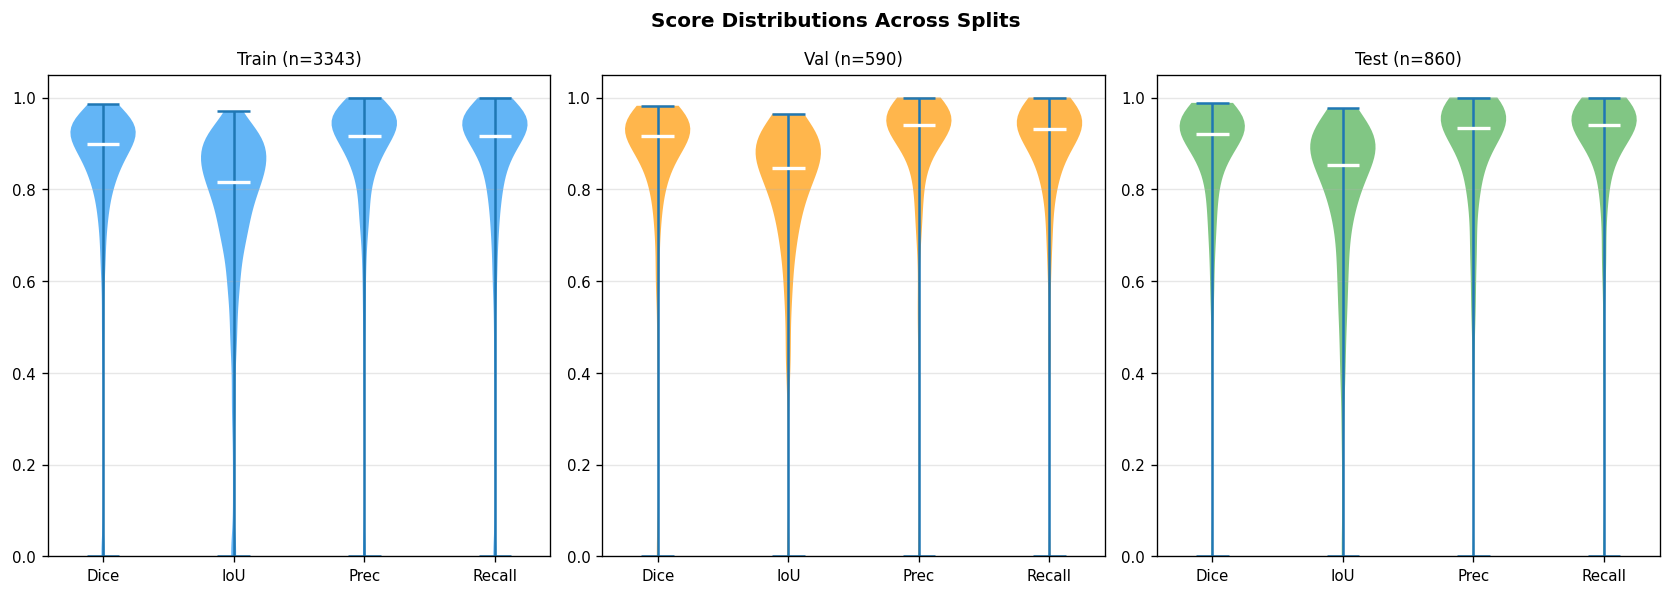

In [ ]:
te_df = pd.DataFrame(te_records)
tr_df = pd.DataFrame(tr_records)
va_df = pd.DataFrame(va_records)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Score Distributions Across Splits', fontsize=12, fontweight='bold')

for ax, (df, label, col) in zip(axes, [
    (tr_df, 'Train', '#2196F3'),
    (va_df, 'Val', '#FF9800'),
    (te_df, 'Test', '#4CAF50'),
]):
    data = [df['dice'].dropna().values, df['iou'].dropna().values, df['precision'].dropna().values, df['recall'].dropna().values]
    vp = ax.violinplot(data, positions=[1,2,3,4], showmedians=True)
    
    for body in vp['bodies']:
        body.set_facecolor(col); body.set_alpha(0.7)
        
    vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(['Dice','IoU','Prec','Recall'])
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{label} (n={len(df)})', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/score_distributions.png', bbox_inches='tight')
plt.show()

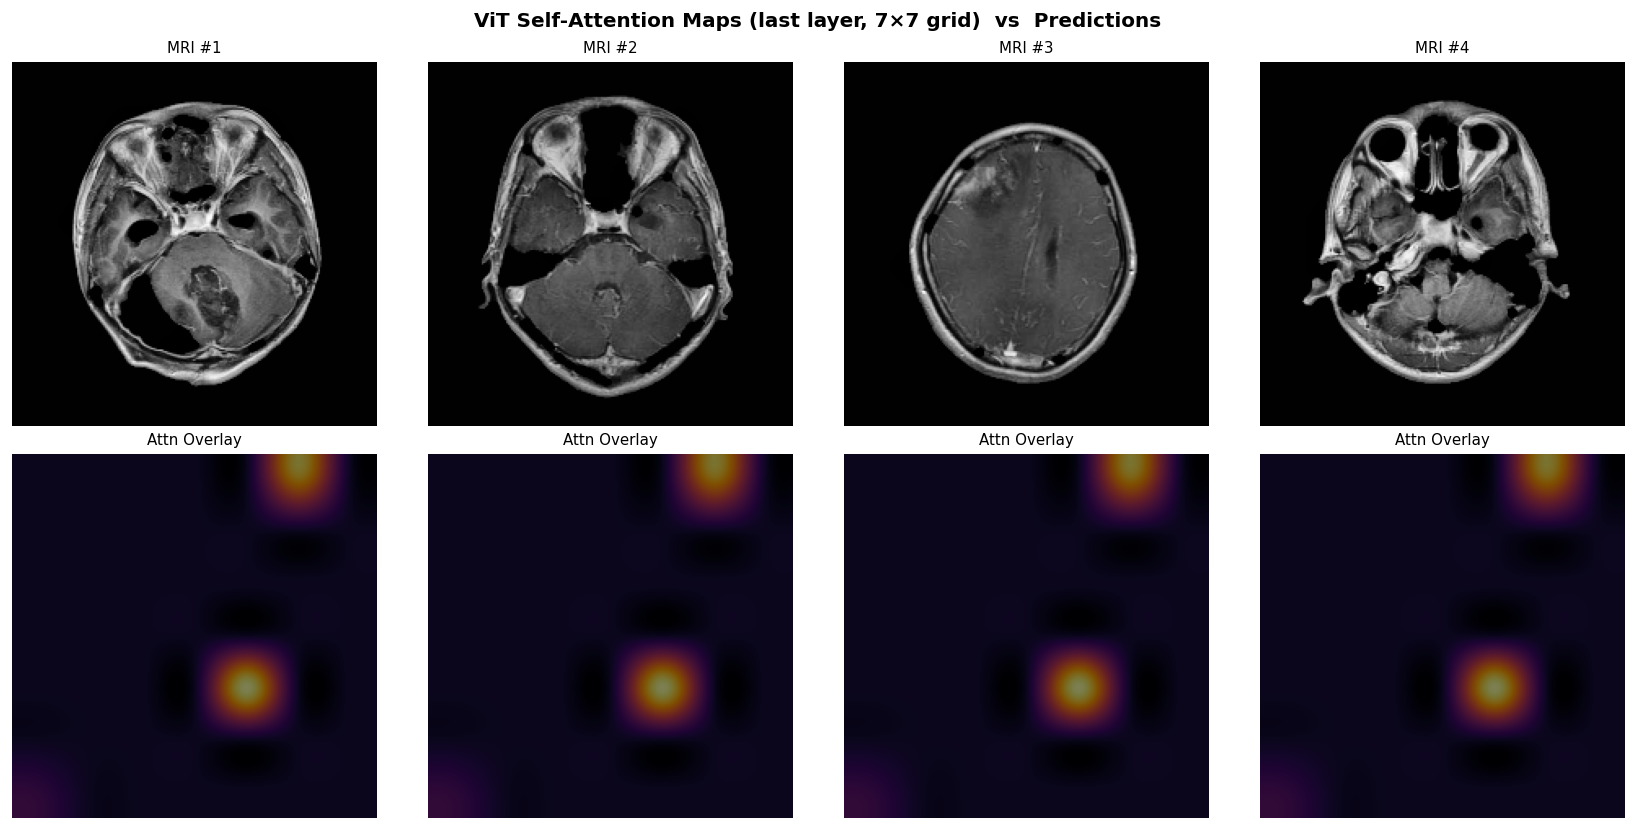

In [89]:
attn_maps = {}
def _save_attn(module, inp, out):
    B, N, C = inp[0].shape
    qkv = module.attn.qkv(inp[0]).reshape(B, N, 3, module.attn.num_heads, module.attn.head_dim).permute(2,0,3,1,4)
    q, k, _ = qkv.unbind(0)
    attn = (q @ k.transpose(-2,-1)) * module.attn.scale
    attn = attn.softmax(dim=-1)         
    attn_maps['last'] = attn.detach().cpu()

hook = model.vit.layers[-1].register_forward_hook(_save_attn)
imgs_batch, _ = next(iter(test_loader))
with torch.no_grad():
    _ = model(imgs_batch.to(CFG.DEVICE))
hook.remove()

attn_w = attn_maps['last'][0]             
attn_w = attn_w.mean(0)                  
attn_w = attn_w.mean(0)                 

N = attn_w.shape[0]
grid = int(N ** 0.5)
assert grid * grid == N, f"N={N} is not a perfect square — check VIT_PATCHES"
attn_w = attn_w.reshape(grid, grid).numpy()
attn_w = (attn_w - attn_w.min()) / (attn_w.max() - attn_w.min() + 1e-8)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(f'ViT Self-Attention Maps (last layer, {grid}×{grid} grid)  vs  Predictions', fontsize=12, fontweight='bold')

for i in range(min(4, len(imgs_batch))):
    img_np = imgs_batch[i, 0].numpy()
    attn_up = cv2.resize(attn_w, (224, 224), interpolation=cv2.INTER_CUBIC)
    attn_up = (attn_up - attn_up.min()) / (attn_up.max() - attn_up.min() + 1e-8)
    img_u8 = (img_np * 255).astype(np.uint8)
    heat_u8 = (attn_up * 255).astype(np.uint8)
    heat_rgb = cv2.applyColorMap(heat_u8, cv2.COLORMAP_INFERNO)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    blend = cv2.addWeighted(img_rgb, 0.5, heat_rgb, 0.5, 0)
    blend = cv2.cvtColor(blend, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_np, cmap='gray'); axes[0, i].set_title(f'MRI #{i+1}', fontsize=9)
    axes[1, i].imshow(blend); axes[1, i].set_title('Attn Overlay', fontsize=9)
    axes[0, i].axis('off'); axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/vit_attention.png', bbox_inches='tight')
plt.show()

## Visualizations 

In [ ]:
from scipy.ndimage import binary_erosion
import random as _random

def get_boundary(binary_mask, thickness=2):
    eroded = binary_erosion(binary_mask.astype(bool), iterations=thickness)
    return binary_mask.astype(bool) & ~eroded

def build_boundary_overlay(img, gt_mask, pred_mask):
    gt_b = get_boundary(gt_mask.astype(bool))
    pred_b = get_boundary(pred_mask.astype(bool))
    both = gt_b & pred_b
    rgb = np.stack([img, img, img], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    rgb[gt_b,0] = 0.0
    rgb[gt_b,1] = 1.0
    rgb[gt_b,2] = 0.0  
    rgb[pred_b,0] = 1.0
    rgb[pred_b,1] = 0.0
    rgb[pred_b,2] = 0.0   
    rgb[both,0] = 1.0
    rgb[both,1] = 1.0
    rgb[both,2] = 0.0   
    return rgb

def iou_from_masks(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    inter = (gt & pred).sum()
    union = (gt | pred).sum()
    return (inter / union * 100) if union > 0 else 0.0

def plot_5_grid(samples_list, title, fname):
    n = len(samples_list)
    fig, axes = plt.subplots(n, 4, figsize=(13, 3.6 * n))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    for col, t in enumerate(['Input MRI', 'Ground Truth', 'Predicted Mask', 'Boundary Overlap']):
        axes[0][col].set_title(t, fontsize=11, fontweight='bold')

    for row, s in enumerate(samples_list):
        img = s['image']
        gt = s['gt'].astype(bool)
        pred = s['pred'].astype(bool)
        ovl = build_boundary_overlay(img, gt, pred)
        iou = iou_from_masks(gt, pred)

        axes[row][0].imshow(img, cmap='gray')
        axes[row][1].imshow(gt, cmap='gray')
        axes[row][2].imshow(pred, cmap='gray')
        axes[row][3].imshow(ovl)
        axes[row][3].text(0.98, 0.02, f'IoU: {iou:.1f}%', transform=axes[row][3].transAxes, fontsize=9, fontweight='bold', color='white',
                          ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6))
        axes[row][0].set_ylabel(f"Dice: {s['dice']:.4f}", fontsize=10)
        for col in range(4):
            axes[row][col].axis('off')

    legend = [
        mpatches.Patch(facecolor='green',  label='GT boundary'),
        mpatches.Patch(facecolor='red',    label='Pred boundary'),
        mpatches.Patch(facecolor='yellow', label='Intersection'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.75, -0.01), framealpha=0.8)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

print('Collecting all test-set predictions …')
model.eval()
_all_samples = []
with torch.no_grad():
    for _imgs, _masks in test_loader:
        _logits = model(_imgs.to(CFG.DEVICE))
        _preds = (torch.sigmoid(_logits) > 0.5).cpu().numpy().astype(np.float32)
        for _i in range(len(_imgs)):
            _p = _preds[_i, 0];  _m = _masks[_i, 0].numpy()
            _d = float((2*(_p*_m).sum() + 1e-6) / (_p.sum() + _m.sum() + 1e-6))
            _all_samples.append({'image': _imgs[_i, 0].numpy(), 'gt': _m, 'pred': _p, 'dice': _d})

_all_sorted = sorted(_all_samples, key=lambda x: x['dice'], reverse=True)
print(f'  Total test samples : {len(_all_samples)}')
print(f'  Best  Dice : {_all_sorted[0]["dice"]:.4f}')
print(f'  Worst Dice : {_all_sorted[-1]["dice"]:.4f}')

  Total test samples : 860
  Best  Dice : 0.9884
  Worst Dice : 0.0000


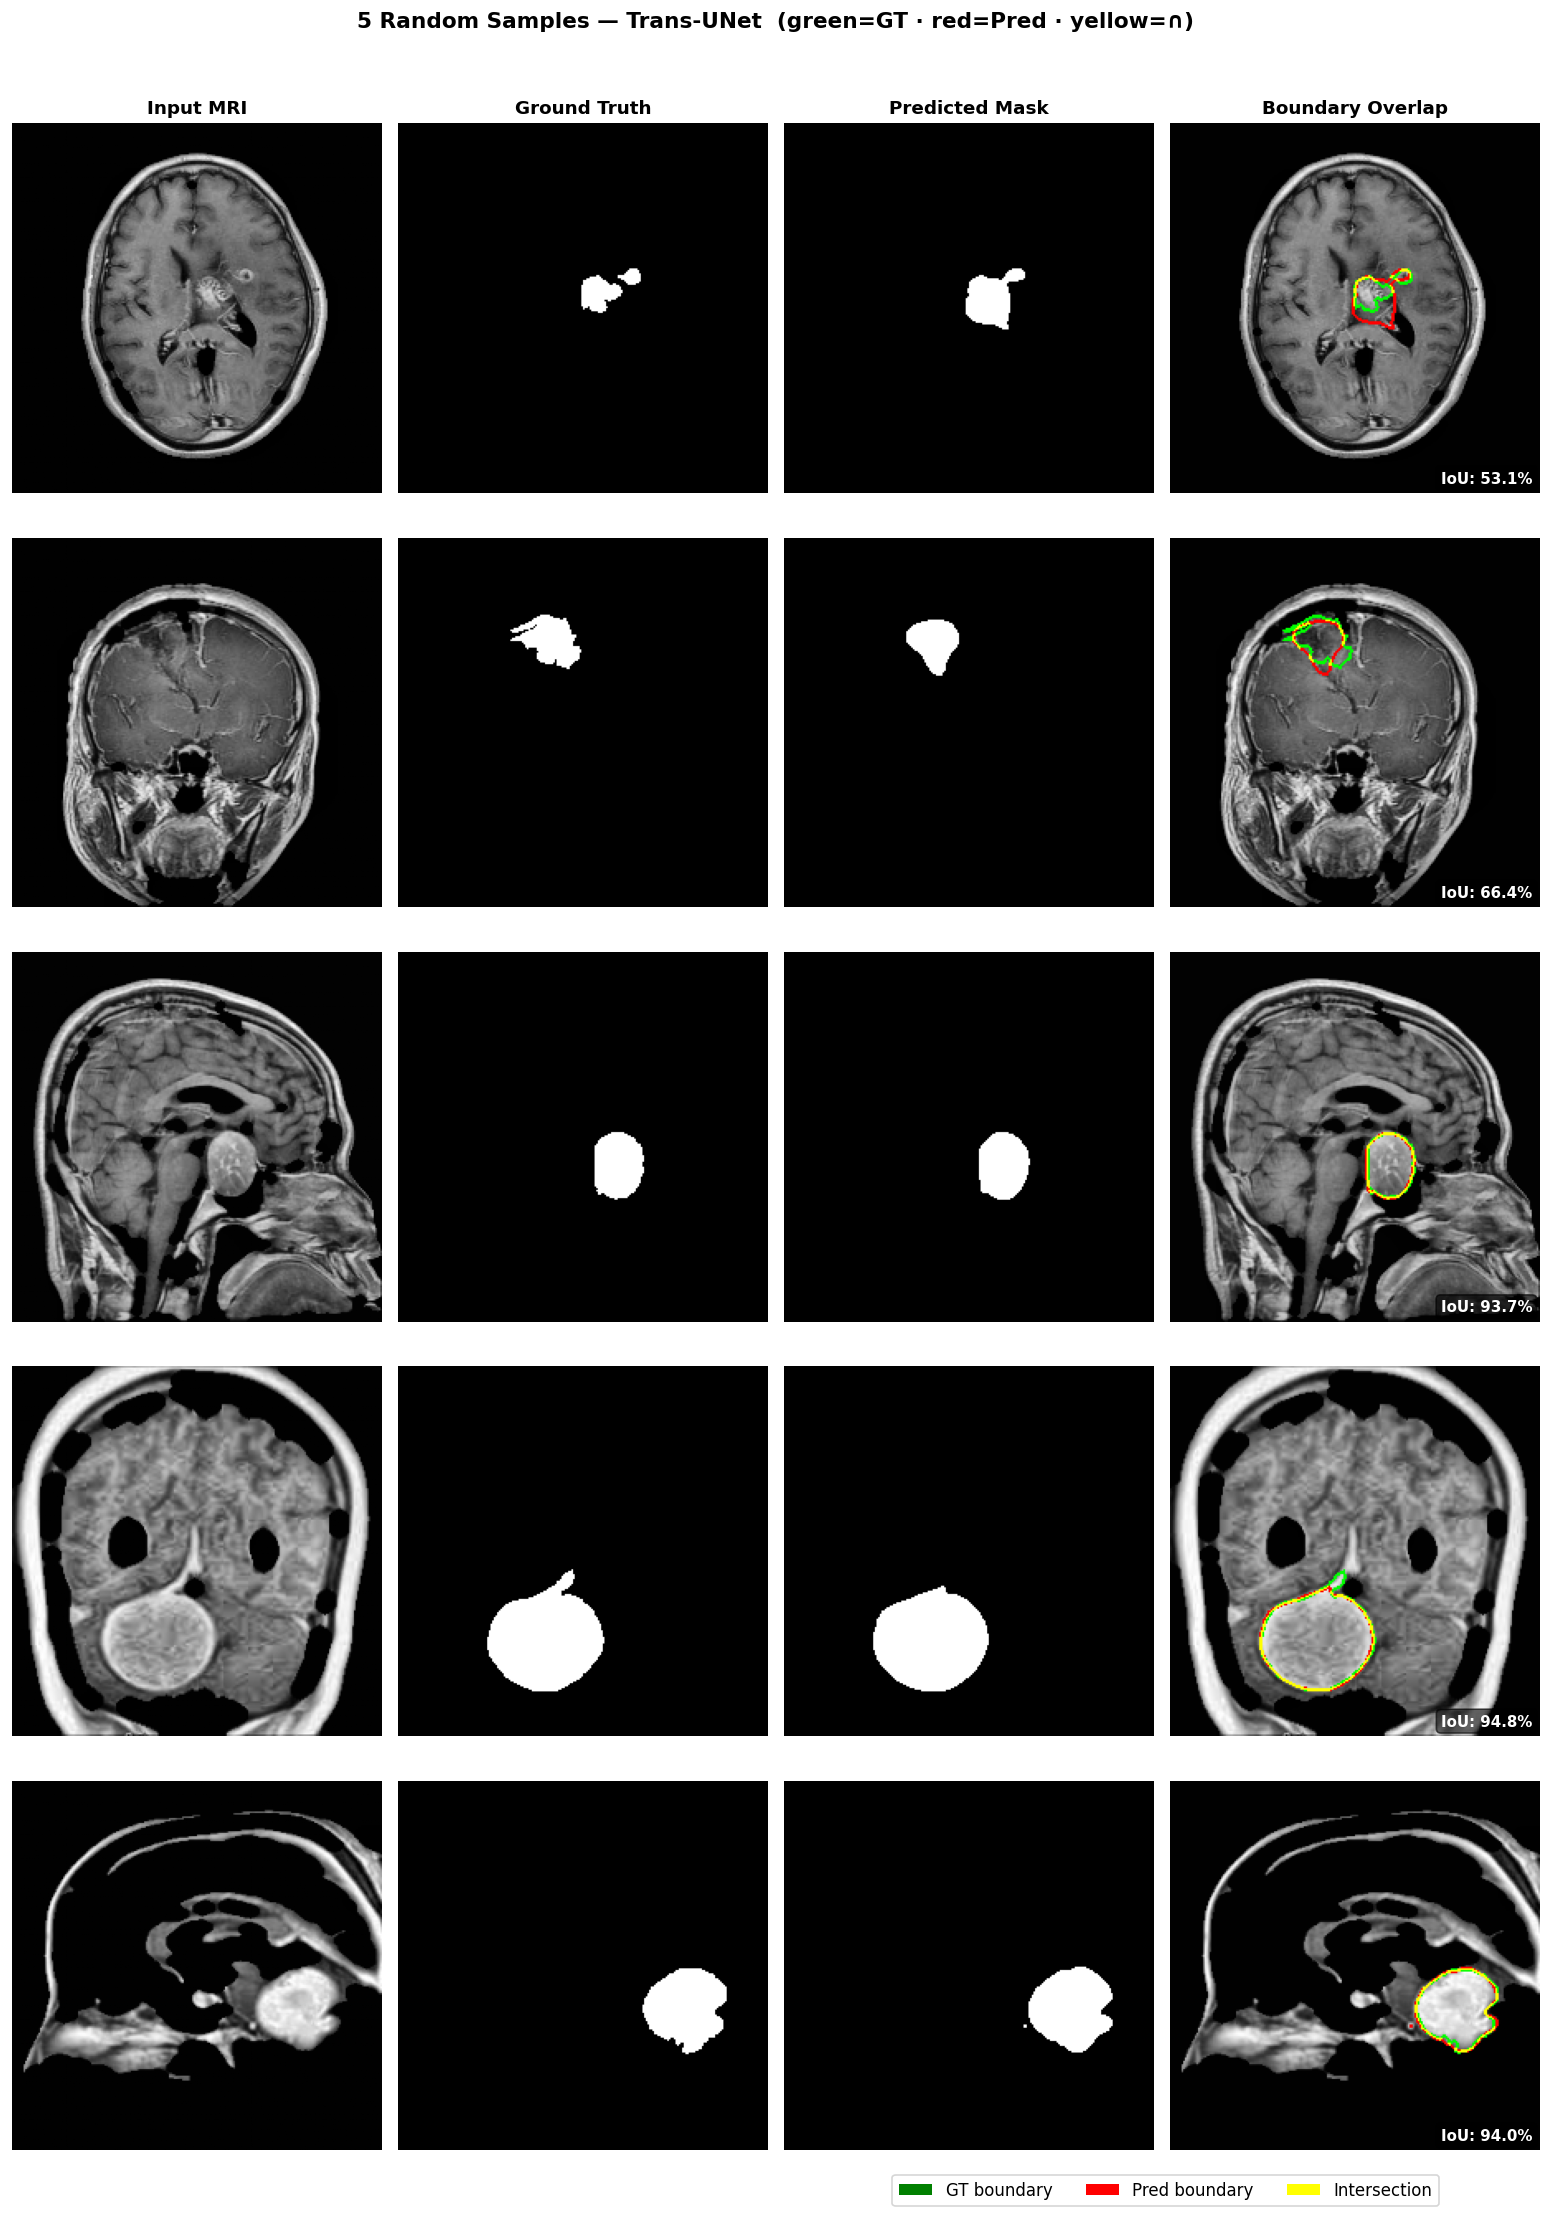

In [ ]:
_random.seed(CFG.SEED)
random_5 = _random.sample(_all_samples, 5)
plot_5_grid(random_5, title='5 Random Samples — Trans-UNet  (green=GT · red=Pred · yellow=∩)', fname='/kaggle/working/viz_random_5.png')

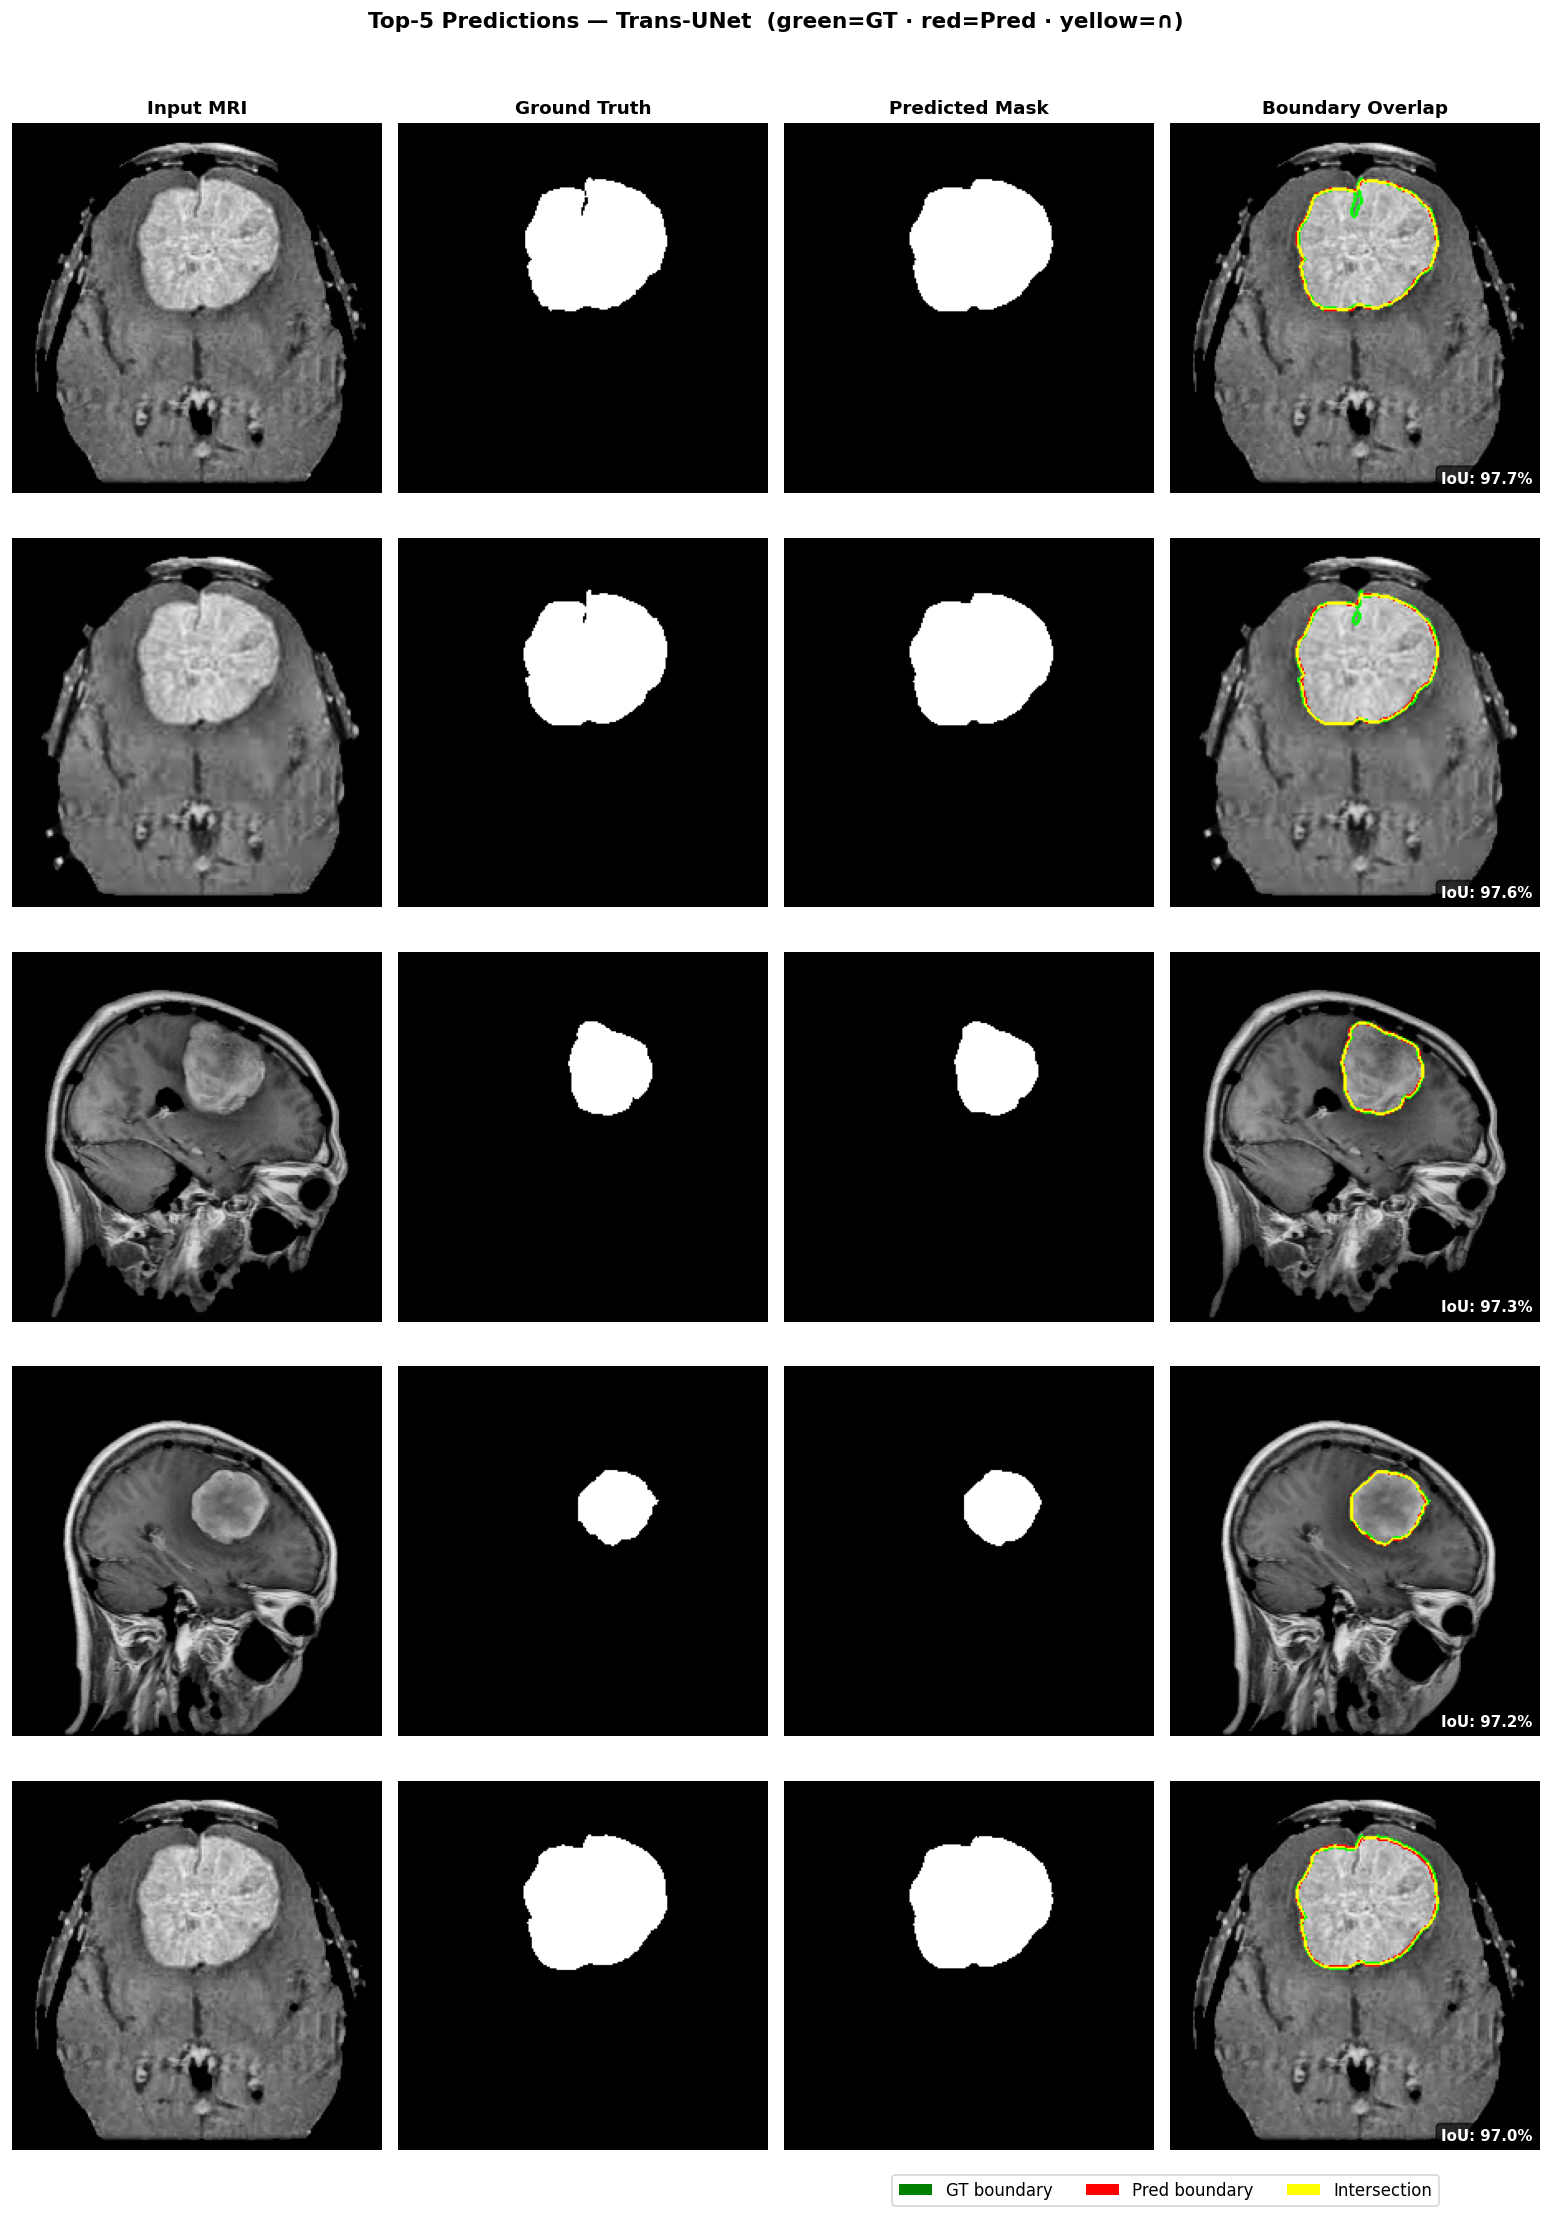

In [ ]:
top_5 = _all_sorted[:5]
plot_5_grid(top_5, title='Top-5 Predictions — Trans-UNet  (green=GT · red=Pred · yellow=∩)', fname='/kaggle/working/viz_top_5.png')

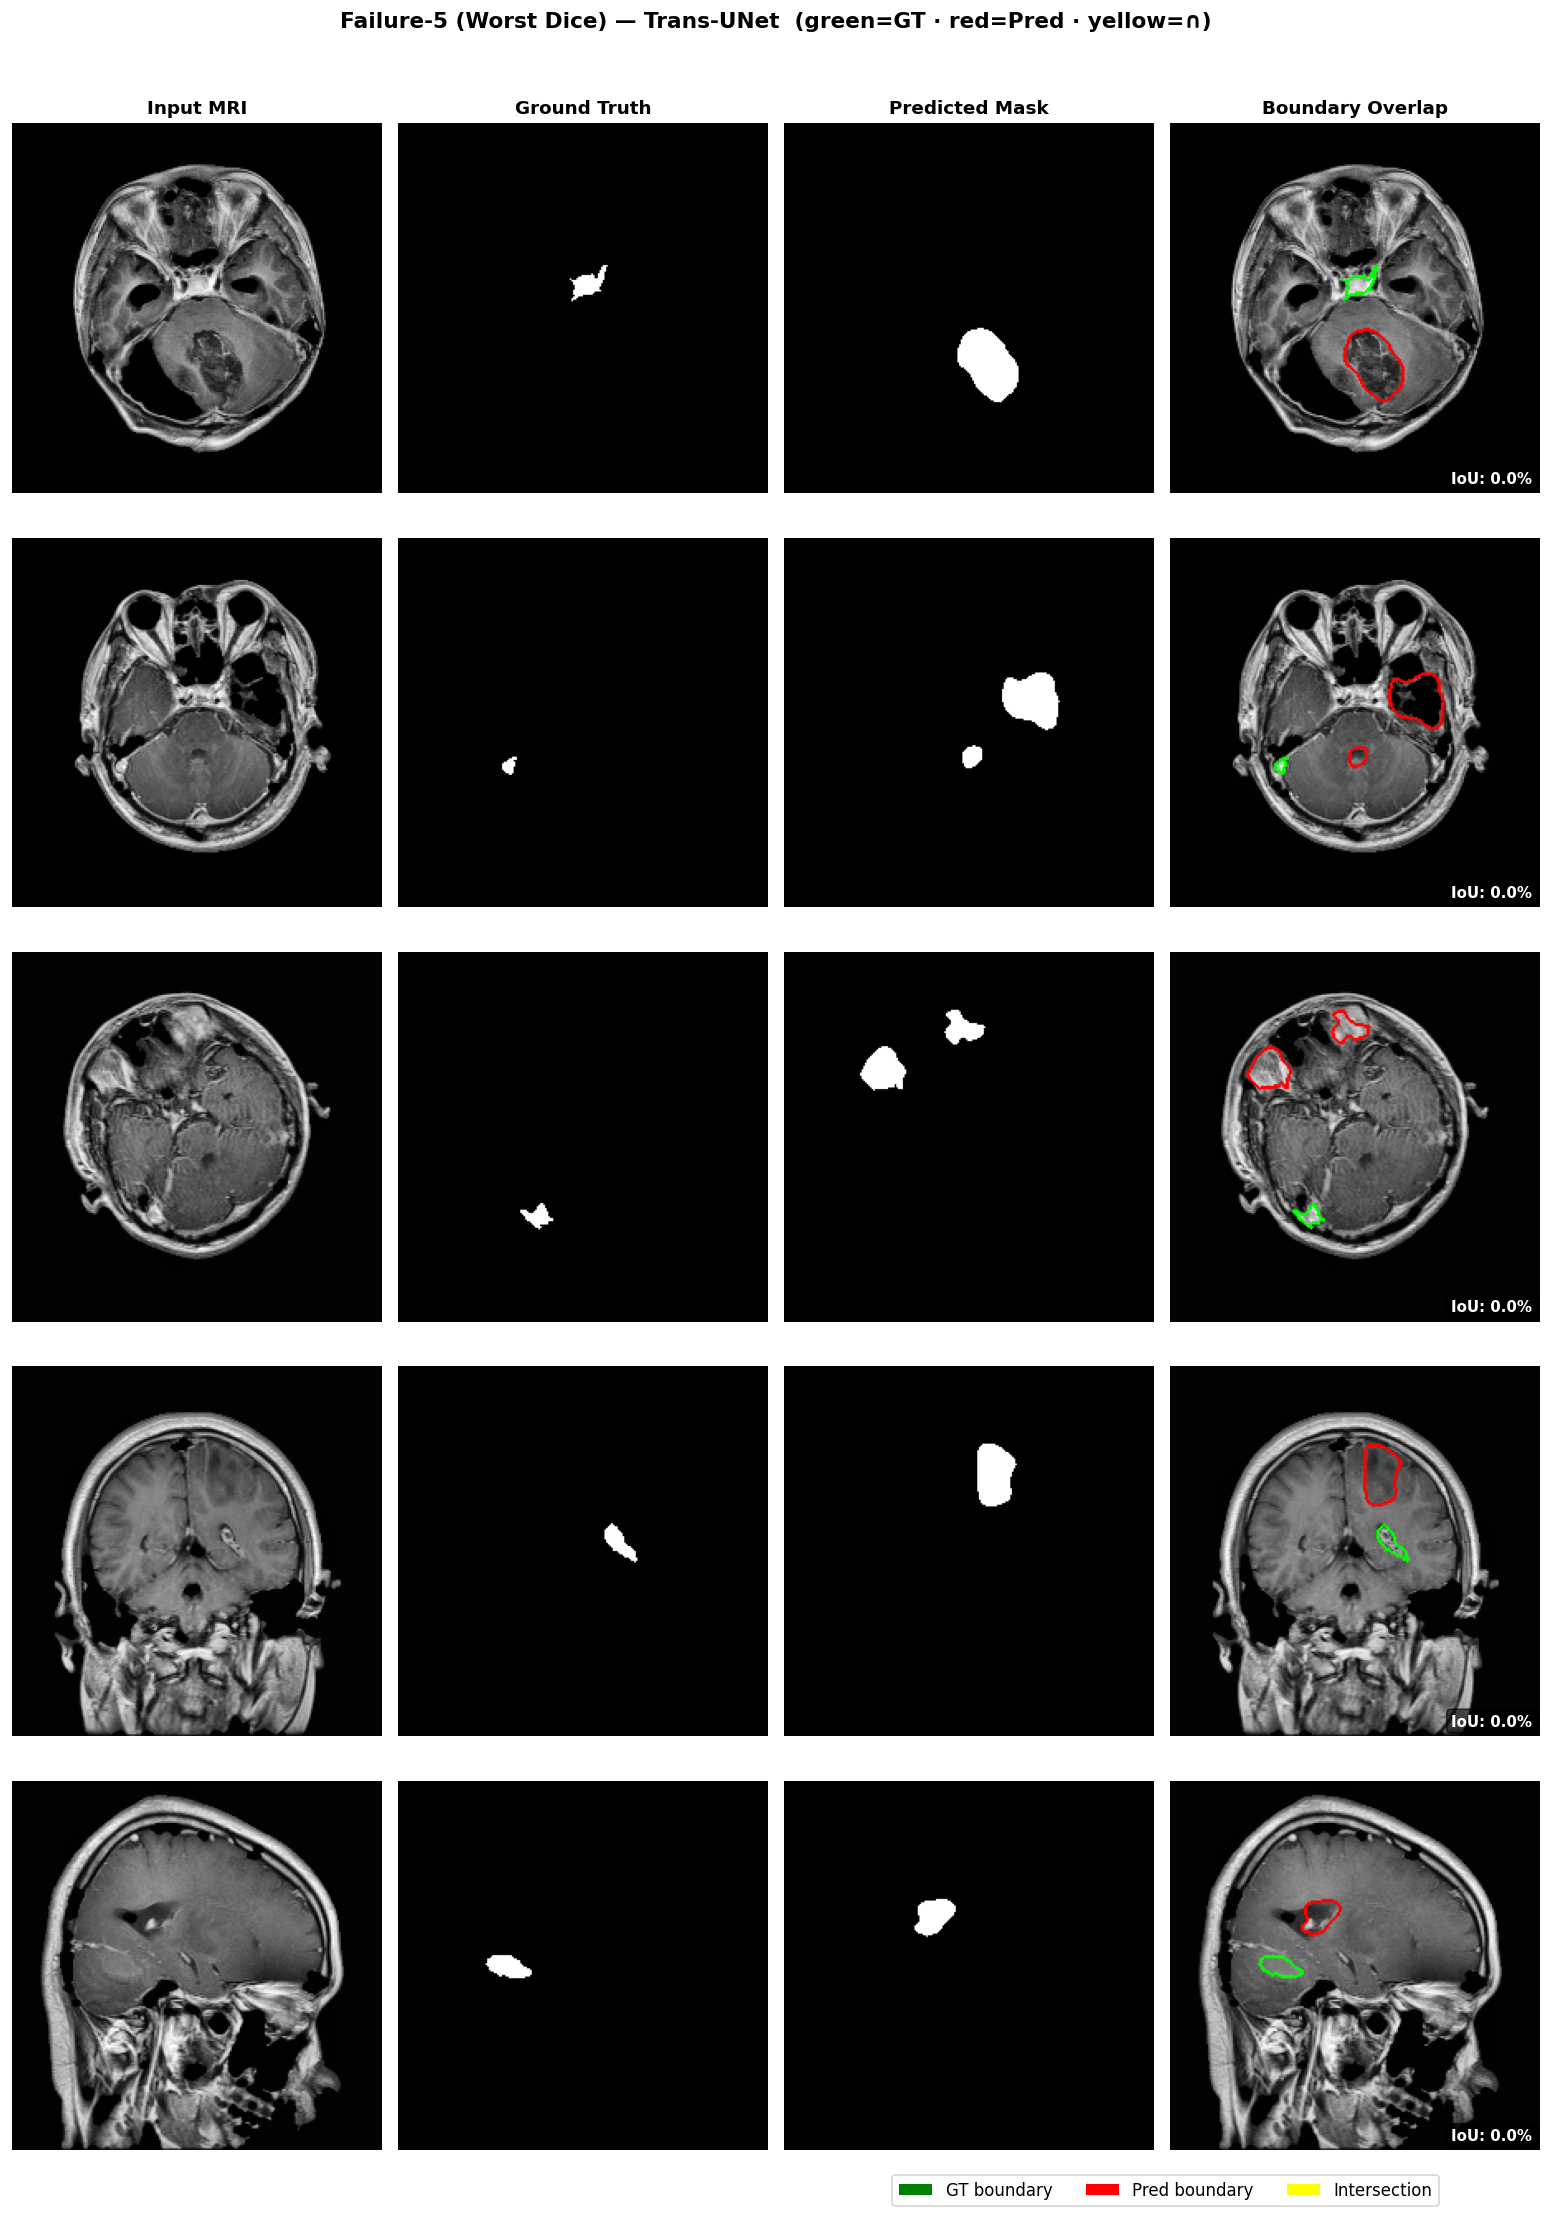

In [ ]:
fail_5 = _all_sorted[-5:][::-1] 
plot_5_grid(fail_5, title='Failure-5 (Worst Dice) — Trans-UNet  (green=GT · red=Pred · yellow=∩)', fname='/kaggle/working/viz_failure_5.png')

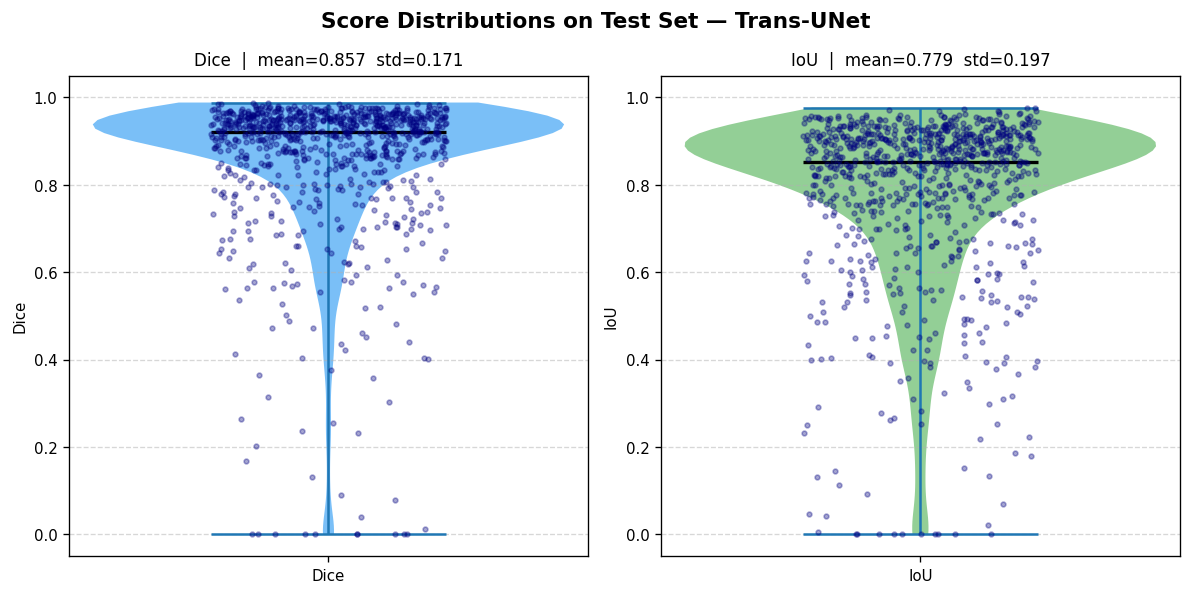

In [95]:
_violin_df = pd.DataFrame([{'Dice': s['dice'], 'IoU' : iou_from_masks(s['gt'], s['pred']) / 100.0} for s in _all_samples])
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Score Distributions on Test Set — Trans-UNet', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['Dice', 'IoU'], ['#42A5F5', '#66BB6A']):
    vals = _violin_df[col].dropna().values
    parts = ax.violinplot(vals, positions=[0], showmedians=True, showextrema=True, widths=0.6)
    for pc in parts['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.7)
        
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    jitter = np.random.uniform(-0.15, 0.15, len(vals))
    ax.scatter(jitter, vals, alpha=0.35, s=8, color='navy', zorder=3)
    ax.set_xticks([0]); ax.set_xticklabels([col])
    ax.set_ylabel(col)
    ax.set_title(f'{col}  |  mean={vals.mean():.3f}  std={vals.std():.3f}', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_violin.png', dpi=150, bbox_inches='tight')
plt.show()

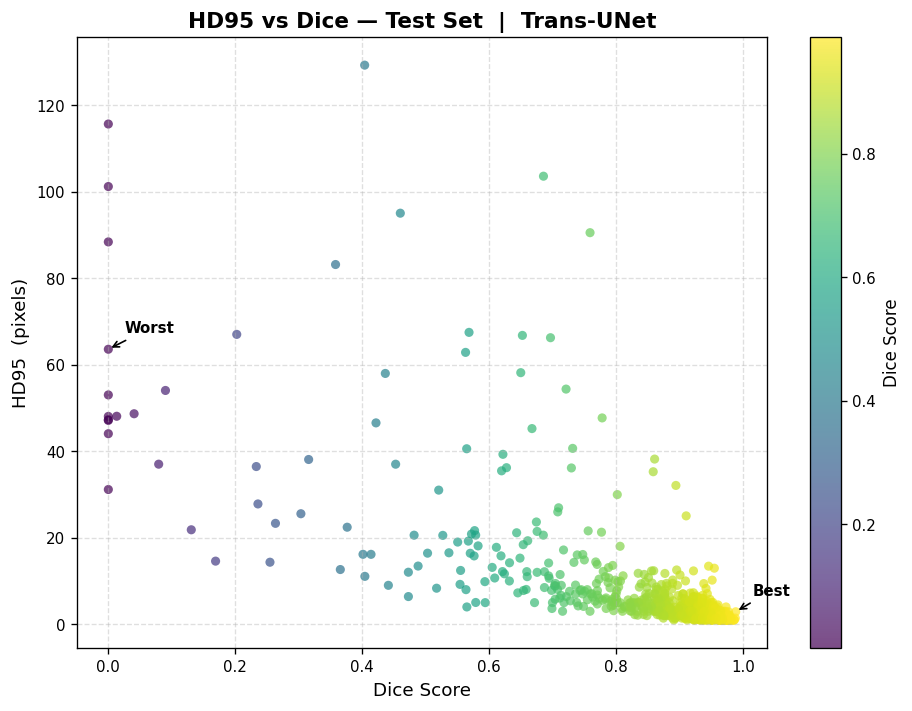

In [ ]:
from medpy.metric.binary import hd95 as _hd95_fn

_scatter_records = []
for s in _all_samples:
    p = s['pred'].astype(np.uint8)
    t = s['gt'].astype(np.uint8)
    h = _hd95_fn(p, t) if (p.sum() > 0 and t.sum() > 0) else np.nan
    _scatter_records.append({'Dice': s['dice'], 'HD95': h})

sc_df = pd.DataFrame(_scatter_records).dropna()
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(sc_df['Dice'], sc_df['HD95'], c=sc_df['Dice'], cmap='viridis', s=30, alpha=0.7, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Dice Score', fontsize=10)
ax.set_xlabel('Dice Score', fontsize=11)
ax.set_ylabel('HD95  (pixels)', fontsize=11)
ax.set_title('HD95 vs Dice — Test Set  |  Trans-UNet', fontsize=13, fontweight='bold')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

best_r = sc_df.loc[sc_df['Dice'].idxmax()]
worst_r = sc_df.loc[sc_df['Dice'].idxmin()]
for r, lbl in [(best_r, 'Best'), (worst_r, 'Worst')]:
    ax.annotate(lbl, xy=(r['Dice'], r['HD95']), xytext=(10, 10), textcoords='offset points',
                fontsize=9, fontweight='bold', arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('/kaggle/working/viz_hd95_dice_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [97]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    @torch.enable_grad()
    def __call__(self, img_tensor):
        self.model.eval()
        img_tensor = img_tensor.to(CFG.DEVICE).requires_grad_(True)
        logits = self.model(img_tensor)
        score = torch.sigmoid(logits).sum()
        self.model.zero_grad()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=img_tensor.shape[2:],
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 1e-8:
            cam /= cam.max()
        return cam

target_layer = model.dec_final.conv[3]
grad_cam = GradCAM(model, target_layer)
print(f'GradCAM hooked on: {target_layer}')

GradCAM hooked on: Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


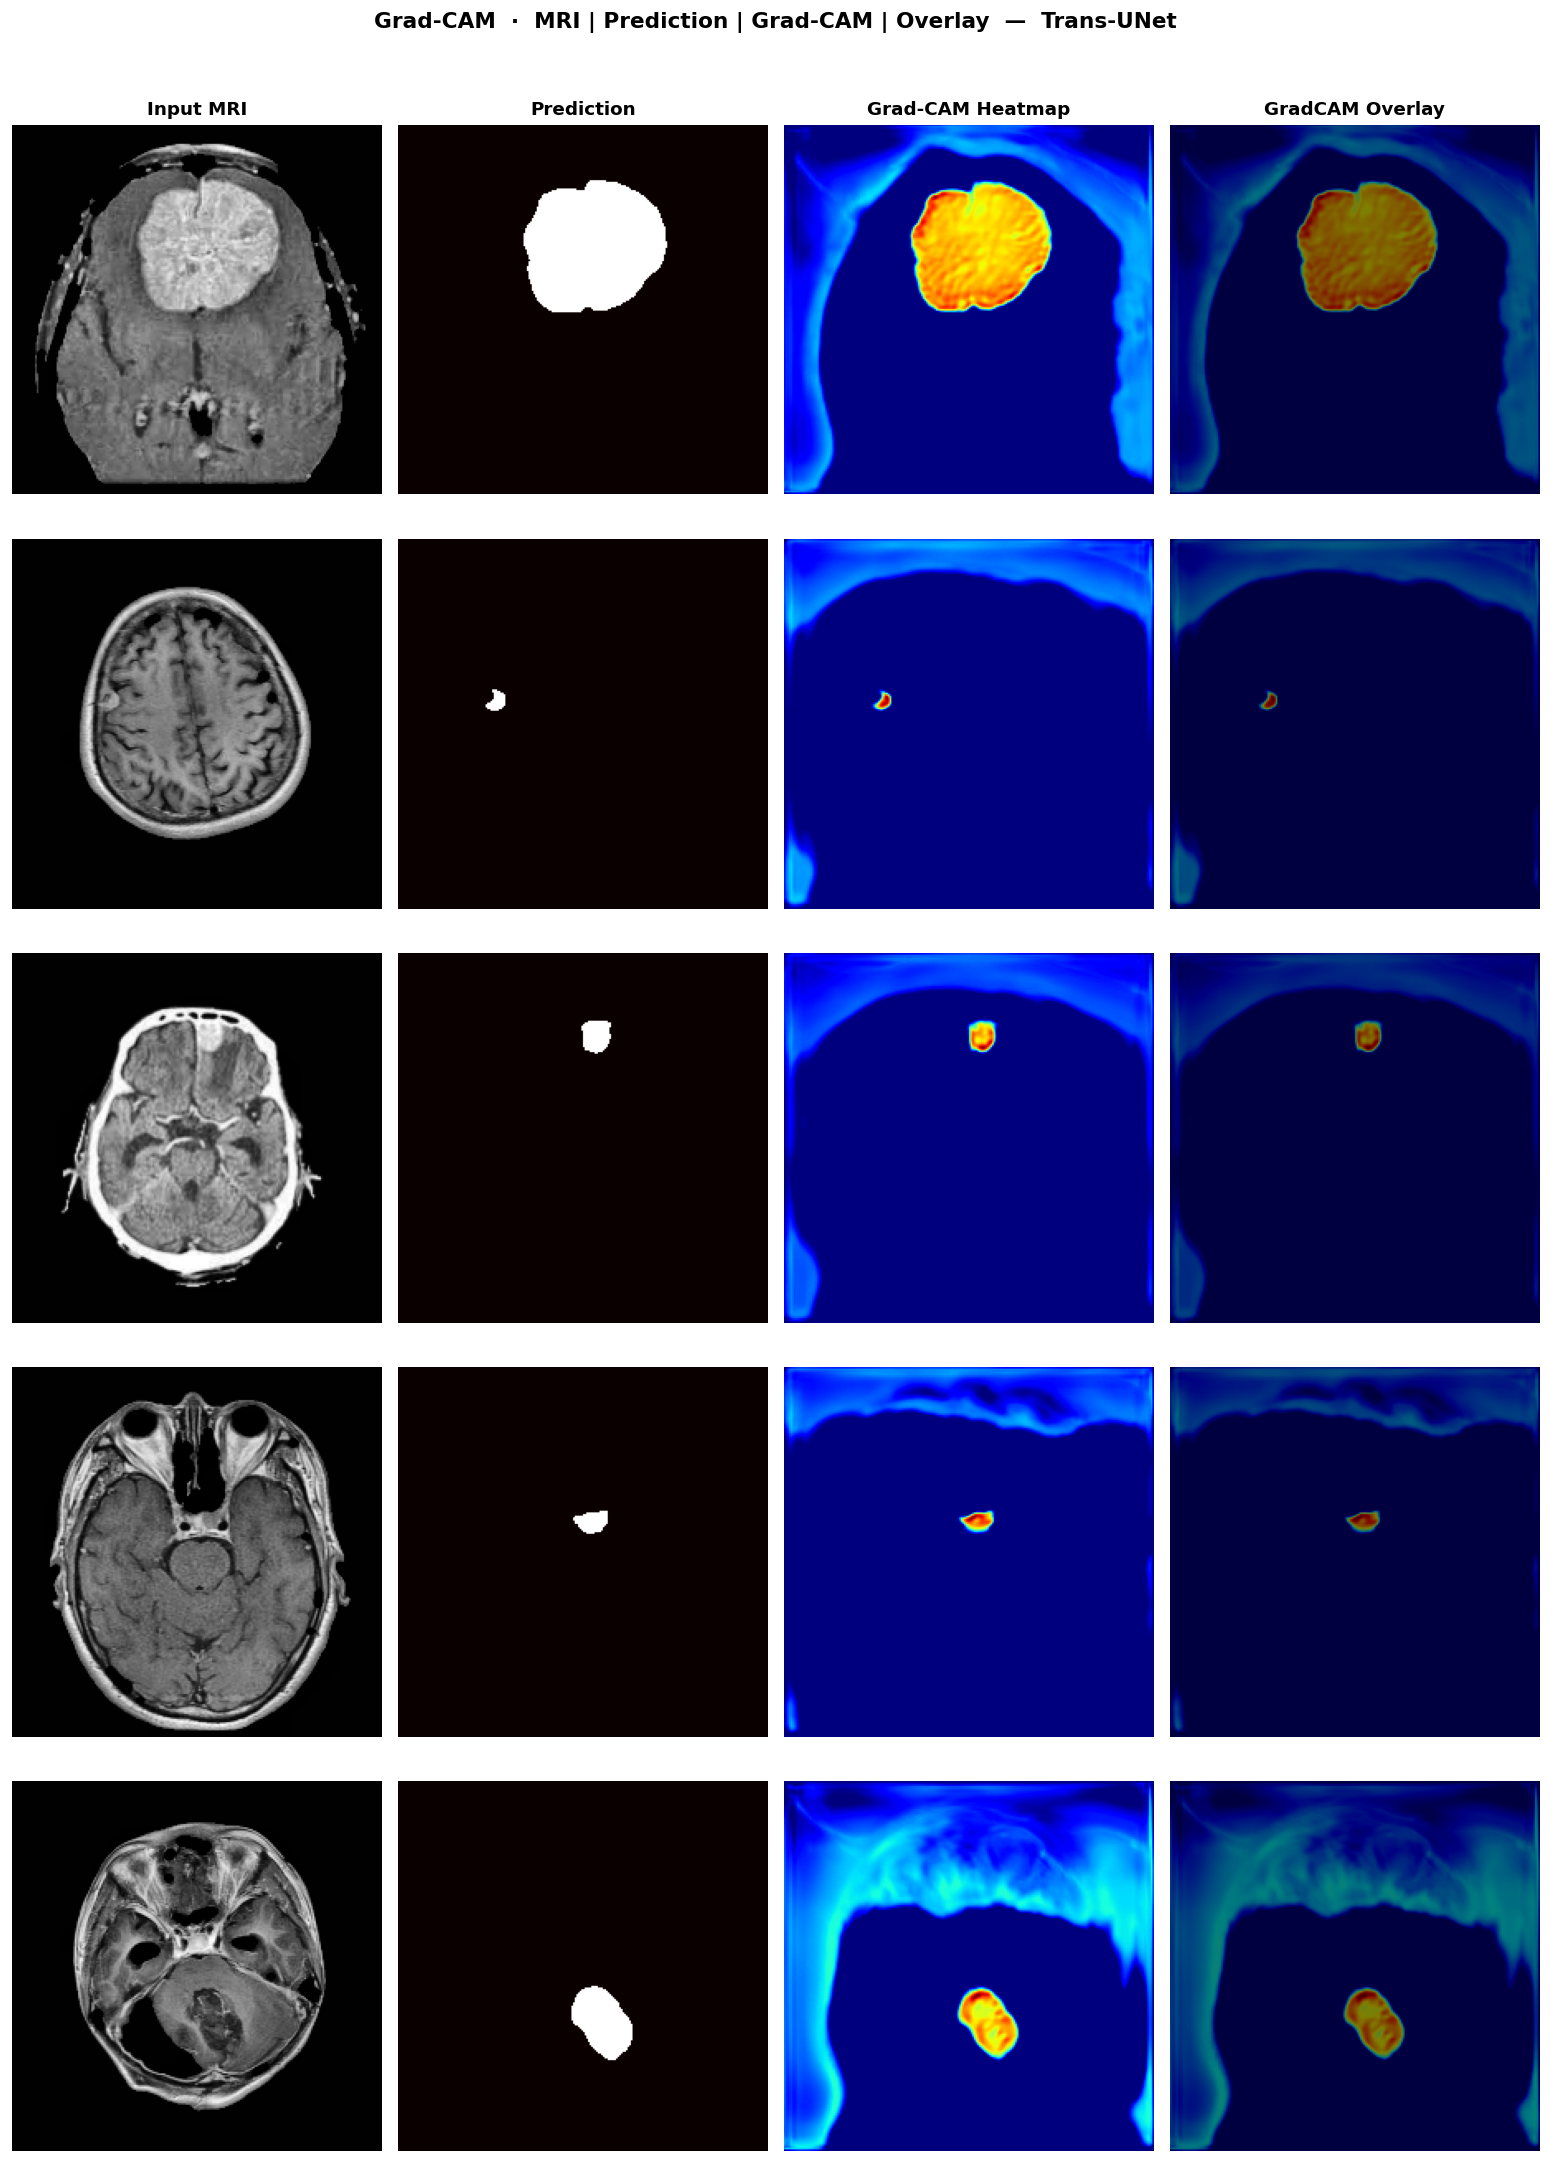

In [98]:
_random.seed(CFG.SEED + 1)
_mid_gc = _all_sorted[1:-1]
_rand3_gc = _random.sample(_mid_gc, 3)
gradcam_5 = [_all_sorted[0]] + _rand3_gc + [_all_sorted[-1]]
labels_gc = ['Best'] + [f'Random {i+1}' for i in range(3)] + ['Worst']

fig, axes = plt.subplots(5, 4, figsize=(13, 3.6 * 5))
fig.suptitle('Grad-CAM  ·  MRI | Prediction | Grad-CAM | Overlay  —  Trans-UNet', fontsize=13, fontweight='bold', y=1.01)

for col, t in enumerate(['Input MRI', 'Prediction', 'Grad-CAM Heatmap', 'GradCAM Overlay']):
    axes[0][col].set_title(t, fontsize=11, fontweight='bold')

for row, (s, lbl) in enumerate(zip(gradcam_5, labels_gc)):
    img_np = s['image']
    pred_np = s['pred']
    img_t = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()
    heatmap = grad_cam(img_t)
    img_u8 = (img_np  * 255).clip(0, 255).astype(np.uint8)
    heat_u8 = (heatmap * 255).clip(0, 255).astype(np.uint8)
    heat_rgb = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    overlay = cv2.addWeighted(img_rgb, 0.5, heat_rgb, 0.5, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(img_np,  cmap='gray')
    axes[row][1].imshow(pred_np, cmap='hot')
    axes[row][2].imshow(heatmap, cmap='jet')
    axes[row][3].imshow(overlay)
    axes[row][0].set_ylabel(f'[{lbl}]\nDice={s["dice"]:.4f}', fontsize=9)
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_gradcam_5.png', dpi=150, bbox_inches='tight')
plt.show()

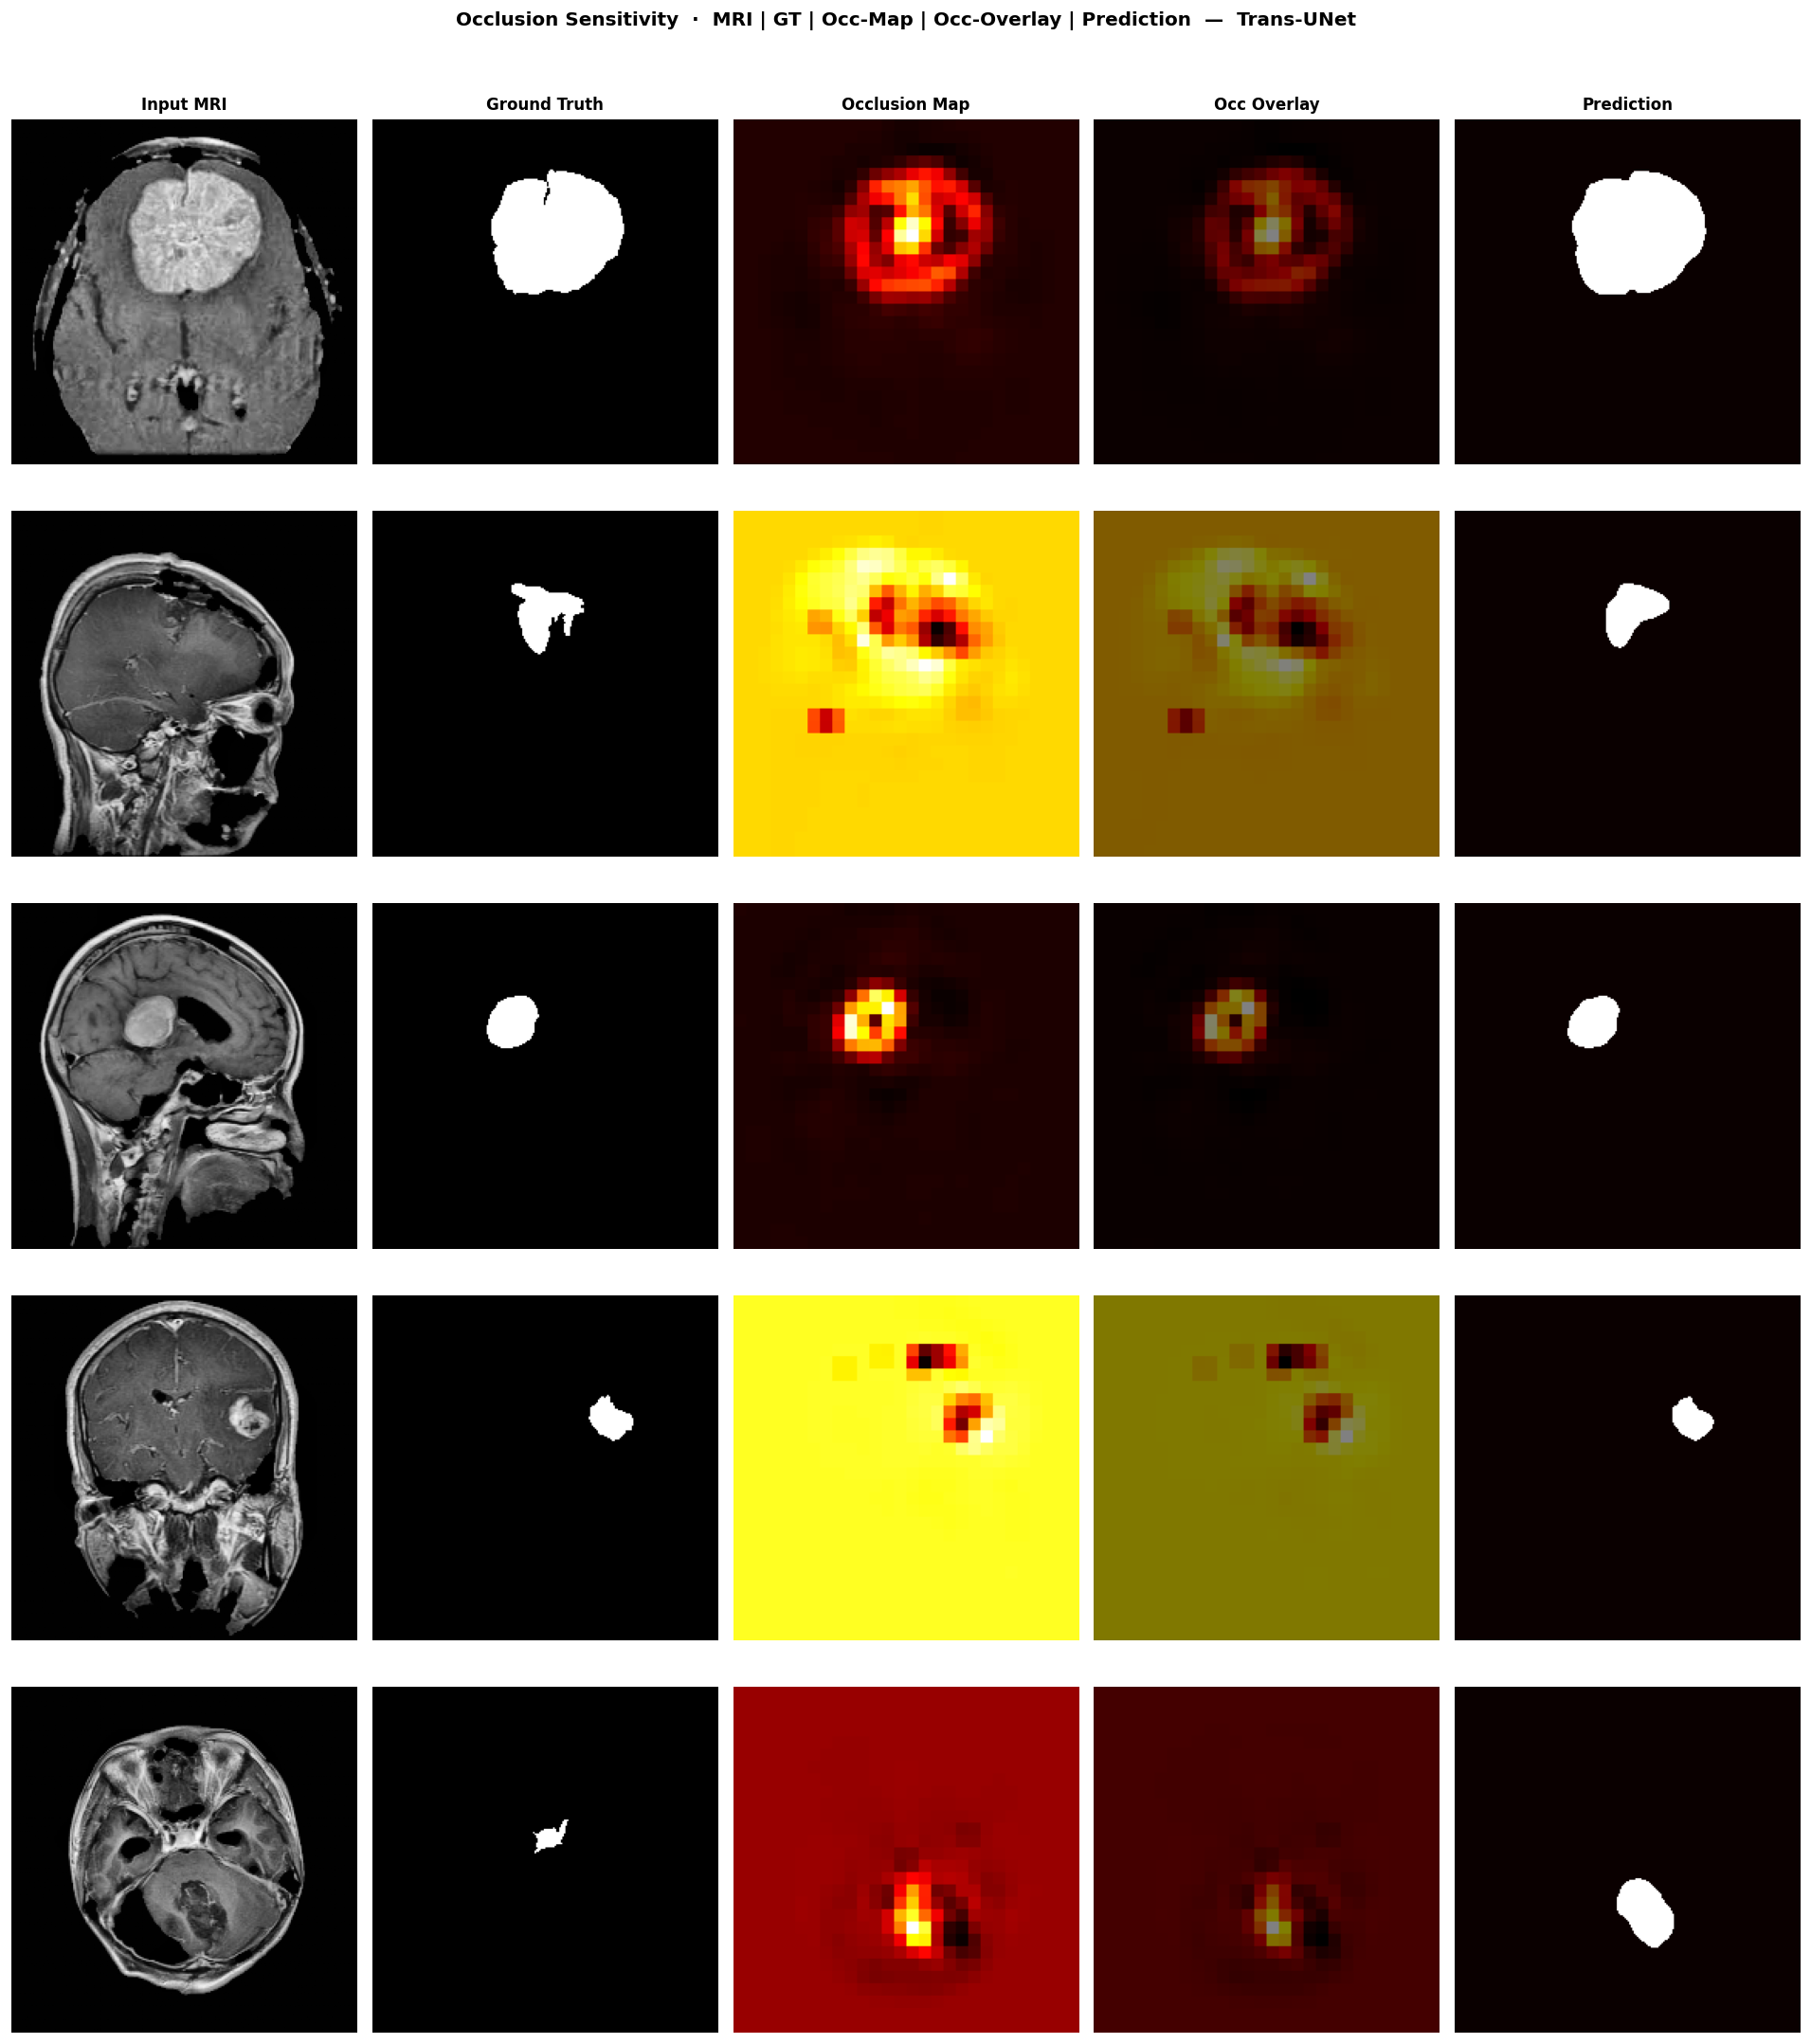

In [99]:
@torch.no_grad()
def occlusion_sensitivity(model, img_np, patch_size=16, stride=8, device=CFG.DEVICE):
    model.eval()
    H, W = img_np.shape
    img_t = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(device)
    base = torch.sigmoid(model(img_t)).mean().item()
    occ_map = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occ = img_t.clone()
            occ[:, :, y:y+patch_size, x:x+patch_size] = 0.0
            drop = base - torch.sigmoid(model(occ)).mean().item()
            occ_map[y:y+patch_size, x:x+patch_size] += drop
            count  [y:y+patch_size, x:x+patch_size] += 1.0

    occ_map /= np.maximum(count, 1e-8)
    occ_map -= occ_map.min()
    if occ_map.max() > 1e-8: occ_map /= occ_map.max()
    return occ_map

_random.seed(CFG.SEED + 2)
_mid_occ = _all_sorted[1:-1]
_rand3_occ = _random.sample(_mid_occ, 3)
occ_5 = [_all_sorted[0]] + _rand3_occ + [_all_sorted[-1]]
labels_occ = ['Best'] + [f'Random {i+1}' for i in range(3)] + ['Worst']

fig, axes = plt.subplots(5, 5, figsize=(16, 3.6 * 5))
fig.suptitle('Occlusion Sensitivity  ·  MRI | GT | Occ-Map | Occ-Overlay | Prediction  —  Trans-UNet', fontsize=12, fontweight='bold', y=1.01)

for col, t in enumerate(['Input MRI', 'Ground Truth', 'Occlusion Map', 'Occ Overlay', 'Prediction']):
    axes[0][col].set_title(t, fontsize=10, fontweight='bold')

for row, (s, lbl) in enumerate(zip(occ_5, labels_occ)):
    img_np = s['image']
    occ_map = occlusion_sensitivity(model, img_np)
    img_u8 = (img_np  * 255).clip(0, 255).astype(np.uint8)
    occ_u8 = (occ_map * 255).clip(0, 255).astype(np.uint8)
    occ_rgb = cv2.applyColorMap(occ_u8, cv2.COLORMAP_HOT)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    occ_ovl = cv2.addWeighted(img_rgb, 0.5, occ_rgb, 0.5, 0)
    occ_ovl = cv2.cvtColor(occ_ovl, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(img_np, cmap='gray')
    axes[row][1].imshow(s['gt'], cmap='gray')
    axes[row][2].imshow(occ_map, cmap='hot')
    axes[row][3].imshow(occ_ovl)
    axes[row][4].imshow(s['pred'], cmap='hot')
    axes[row][0].set_ylabel(f'[{lbl}]\nDice={s["dice"]:.4f}', fontsize=9)
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_occlusion_5.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary

In [100]:
total_params, _ = count_params(model)
te_df = pd.DataFrame(te_records)

print('=' * 72)
print('FINAL SUMMARY — BRISC-25  Trans-UNet Brain MRI Segmentation')
print('=' * 72)
print(f'  Best epoch       : {best_epoch} / {CFG.EPOCHS}')
print(f'  Total parameters : {total_params:,}  ({total_params/1e6:.1f} M)')
print(f'  ViT layers       : {CFG.VIT_LAYERS}  |  heads: {CFG.VIT_HEADS}  |  dim: {CFG.VIT_HIDDEN}')
print(f'  Image size       : {CFG.IMAGE_SIZE}x{CFG.IMAGE_SIZE}')
print(f'  Batch size       : {CFG.BATCH_SIZE}')
print(f'  Optimizer        : AdamW  (lr={CFG.LR}, wd={CFG.WEIGHT_DECAY})')
print(f'  Scheduler        : CosineAnnealingLR')
print()

metrics_map = {
    'Dice':'dice','IoU':'iou','HD95':'hd95',
    'Precision':'precision','Recall':'recall','Specificity':'specificity',
}
print(f"| {'Metric':<14} | {'Test Mean':>12} | {'Test Std':>10} |")
print(f"|{'-'*16}|{'-'*14}|{'-'*12}|")
for display, col in metrics_map.items():
    vals = te_df[col].dropna()
    print(f"| {display:<14} | {vals.mean():>12.4f} | {vals.std():>10.4f} |")

print()
print(f'  Best Val Dice    : {best_val_dice:.4f}')
print(f'  Checkpoint       : {CFG.BEST_CKPT}')
print('=' * 72)

FINAL SUMMARY — BRISC-25  Trans-UNet Brain MRI Segmentation
  Best epoch       : 92 / 100
  Total parameters : 116,121,937  (116.1 M)
  ViT layers       : 12  |  heads: 12  |  dim: 768
  Image size       : 224x224
  Batch size       : 8
  Optimizer        : AdamW  (lr=0.0001, wd=1e-05)
  Scheduler        : CosineAnnealingLR

| Metric         |    Test Mean |   Test Std |
|----------------|--------------|------------|
| Dice           |       0.8572 |     0.1712 |
| IoU            |       0.7790 |     0.1971 |
| HD95           |       7.0788 |    13.4179 |
| Precision      |       0.8634 |     0.1820 |
| Recall         |       0.8784 |     0.1735 |
| Specificity    |       0.9982 |     0.0030 |

  Best Val Dice    : 0.8645
  Checkpoint       : /kaggle/working/models/transunet_best.pth
